# COMP 579 Assignment 1

1. Do Not Change the Random Seed
The random seed has been set to ensure reproducibility. Please do not modify it.

2. Guidance for the First Question
For the initial question, fill in the blanks under the sections marked as TODO. Follow the provided structure and complete the missing parts.

3. Approach for Subsequent Questions
For the later questions, we expect you to attempt the solutions independently. You can refer to the examples provided in earlier questions to understand how to 
plot figures and implement solutions.

4. Ensure that the plots you produce for later questions are similar in style and format to those shown in the previous examples.

In [1]:
%matplotlib inline
import random
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(40)

plt.rcParams["figure.figsize"]=10,5

## Q1 Simulator for Gaussian Bandit

In [2]:

class GaussianBandit:
  """
    A class representing a Gaussian multi-armed bandit.

    Attributes
    ----------
    num_arms : int
        Number of arms in the bandit.
    mean : list or np.ndarray
        List of mean rewards for each arm.
    variance : float
        Variance of the rewards for all arms.

    Methods
    -------
    sample(arm_index)
        Samples a reward from the specified arm based on a Gaussian distribution.
    """

  # TODO:
  def __init__(self, num_arms, mean, variance):
    self.num_arms = num_arms # k arms
    self.mean = mean # input mean
    self.variance = variance # assume fixed variance for all arms (set during input)

  def sample(self, arm_index):
    # sample reward from Gaussian distribution
    return np.random.normal(self.mean[arm_index], self.variance)

In [3]:
# TODO:
delta = 0.2
num_arms = 3
means = [0.5, 0.5 - delta, 0.5 + delta]
variance = 0.01
num_samples = 50

three_arm_gaussian_bandit = GaussianBandit(num_arms, means, variance)

# Store the rewards for each arm
action_rewards = []
actions = range(num_arms)

for action in actions:
    # Store 50 samples per action
    rewards = [three_arm_gaussian_bandit.sample(action) for _ in range(num_samples)]
    action_rewards.append(rewards)

### Graphs

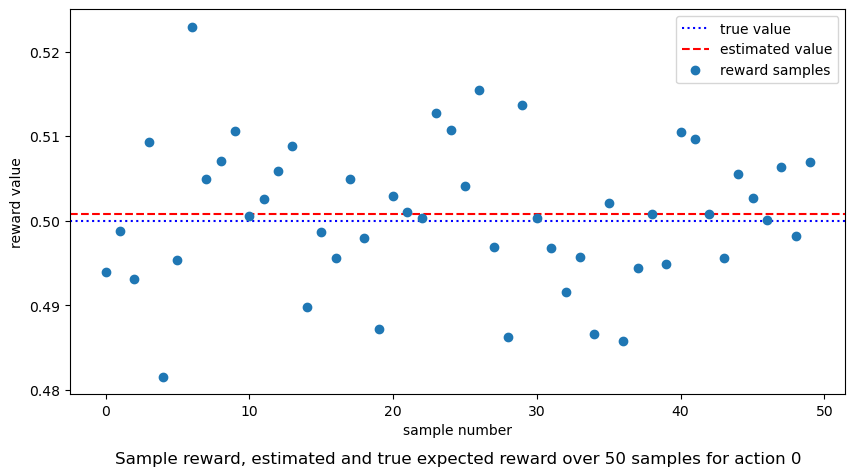

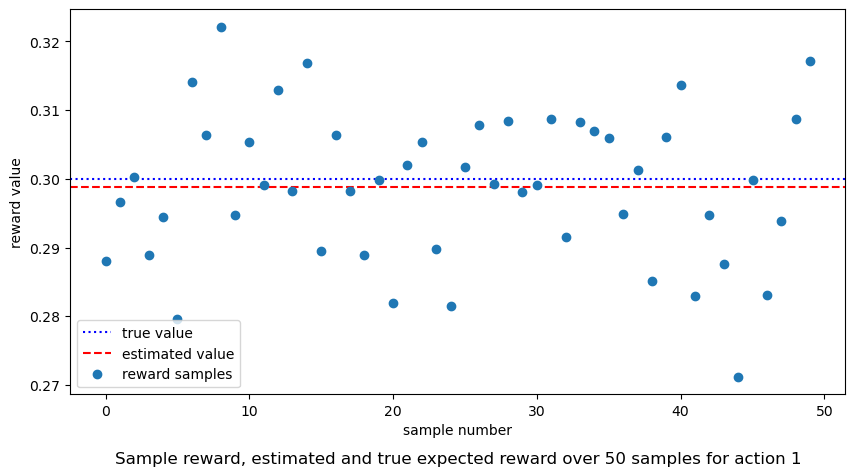

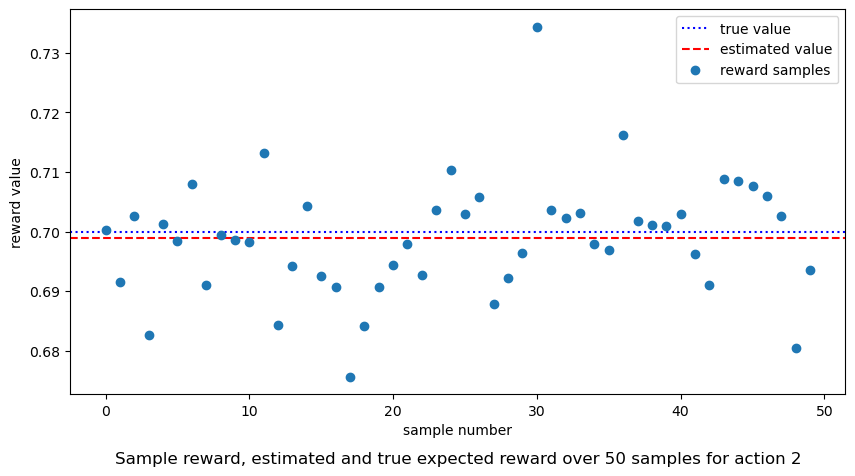

In [4]:
for action in actions:
  fig, ax = plt.subplots()

  # TODO:
  true_value = means[action] # true value of the action
  # sample mean of the rewards for the action
  estimated_value = np.mean(action_rewards[action])

  # draw the line of the true value
  line_true_val = ax.axhline(y = true_value, color = 'b', linestyle = ':', label = "true value")
  # draw the line of the estimated value
  line_est_val = ax.axhline(y = estimated_value, color = 'r', linestyle = '--', label = "estimated value")
  # plot the reward samples
  plt_samples, = ax.plot(action_rewards[action], 'o', label = "reward samples")

  ax.set_xlabel("sample number")
  ax.set_ylabel("reward value")
  ax.set_title("Sample reward, estimated and true expected reward over 50 samples for action %s" %action, y=-0.2)

  # show the legend with the labels of the line
  ax.legend(handles=[line_true_val, line_est_val, plt_samples])

## Q2 Estimated Q values

In [5]:
def update(reward_samples, alpha):
  """
  Each call to the function yields the current incremental average of the reward with a fixed learning rate, alpha
  E.g. Inital call returns alpha * reward_samples[0], second call returns prev_val + alpha * (reward_samples[1] - prev_val)
  where prev_val is the value return from the previous call, so on and so forth

  Parameters
  ----------
  reward_samples : array of int
      samples of reward values from one arm of a bandit
  alpha : int
      learning rate parameter for the averaging
  """
  prev_val = 0
  for reward in reward_samples:
    prev_val = prev_val + alpha * (reward - prev_val)
    yield prev_val

def updateAvg(reward_samples):
  """
  Each call to the function yields the current incremental average of the reward
  E.g. Inital call returns reward_samples[0], second call returns the average of reward_samples[0] and reward_samples[0], so on and so forth

  Parameters
  ----------
  reward_samples : array of int
      samples of reward values from one arm of a bandit
  """
  reward_sum = 0
  count = 0
  for reward in reward_samples:
    reward_sum += reward
    count += 1
    avg = reward_sum / count
    yield avg
    
def updateDecaying(reward_samples, alpha_0=0.5, lambda_=0.01, p=0.5):
    """
    Each call to the function yields the updated estimate of the action value using an
    improved decaying learning rate.

    Parameters
    ----------
    reward_samples : array-like of int or float
        Samples of reward values from one arm of a bandit.
    alpha_0 : float, optional
        The initial learning rate (default is 0.5).
    lambda_ : float, optional
        The decay rate constant (default is 0.01).
    p : float, optional
        The power parameter for controlling decay (default is 0.5).
    """
    prev_val = 0
    for reward in reward_samples:
        alpha = alpha_0 / (1 + lambda_ * (reward - prev_val) ** p)
        prev_val = prev_val + alpha * (reward - prev_val)
        yield prev_val


### Graphs

/Users/nicksmits/opt/anaconda3/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


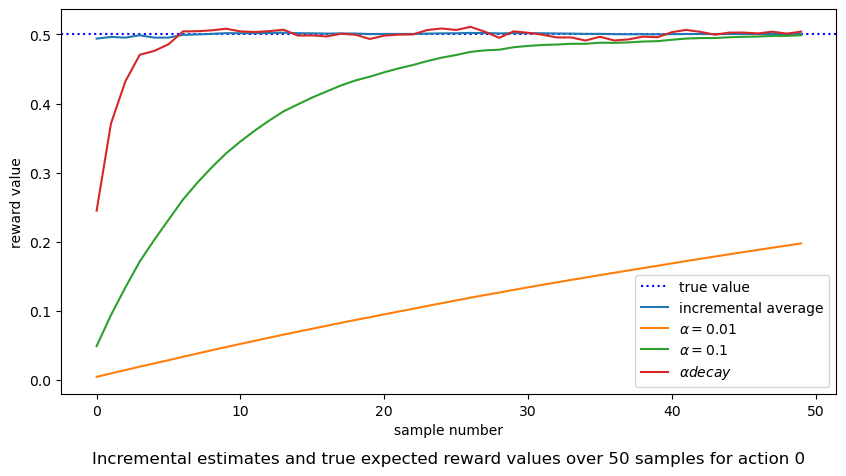

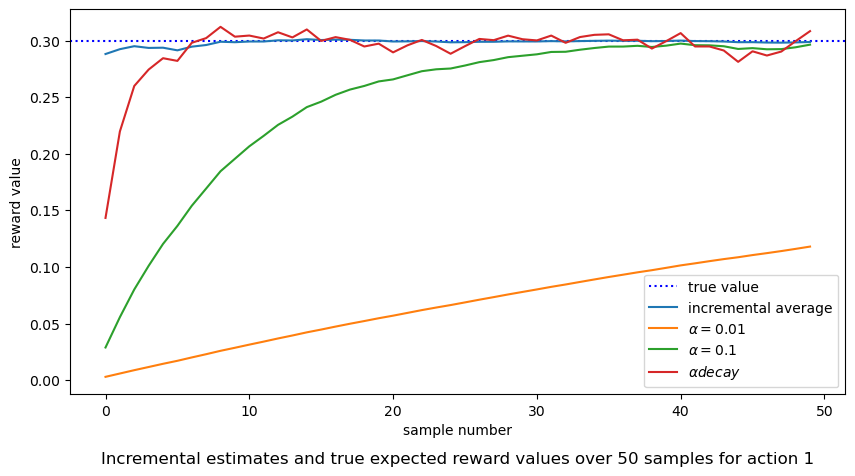

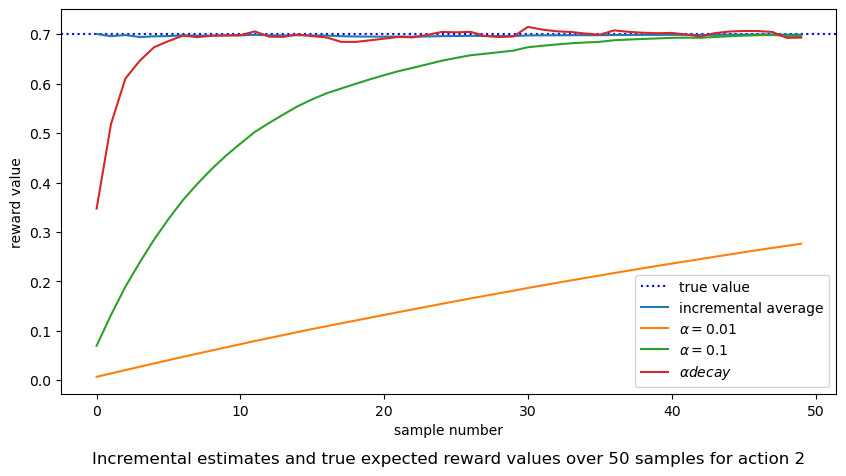

In [6]:
for action in actions:
  fig, ax = plt.subplots()

  # TODO:
  incr_avgs = list(updateAvg(action_rewards[action]))
  alpha_1_percent = list(update(action_rewards[action], 0.01))
  alpha_10_percent = list(update(action_rewards[action], 0.1))
  alpha_decay = list(updateDecaying(action_rewards[action]))
  true_value = means[action] # true value of the action

  # draw the true value line
  line_true_val = ax.axhline(y = true_value, color = 'b', linestyle = ':', label = "true value")

  # plot incremental values for averaging, alpha = 0.01, alpha = 0.1
  plt_incr_avgs, = ax.plot(incr_avgs, label = "incremental average")
  plt_alpha_1_percent, = ax.plot(alpha_1_percent, label = r"$\alpha = 0.01$")
  plt_alpha_10_percent, = ax.plot(alpha_10_percent, label = r"$\alpha = 0.1$")
  plt_alpha_decay, = ax.plot(alpha_decay, label = r"$\alpha decay$")

  ax.set_xlabel("sample number")
  ax.set_ylabel("reward value")
  ax.set_title("Incremental estimates and true expected reward values over 50 samples for action %s" %action, y=-0.2)

  # show the legend with the labels of the line
  ax.legend(handles=[line_true_val, plt_incr_avgs, plt_alpha_1_percent, plt_alpha_10_percent, plt_alpha_decay])

## Q3 Effect of $α$ on Estimated Q values

In [7]:
# TODO:
num_samples = 100

# arrays of the data generated from 100 runs
incr_avgs_runs = []
alpha_1_percent_runs = []
alpha_10_percent_runs = []
alpha_decay_runs = []


# TODO:
for run in range(100):
  # arrays of data generated from the 3 actions in 1 run
  sample_incr_avgs_by_actions = []
  sample_alpha_1_percent_by_actions = []
  sample_alpha_10_percent_by_actions = []
  sample_alpha_decay_by_actions = []

  for action in actions:
    rewards = [three_arm_gaussian_bandit.sample(action) for _ in range(num_samples)]
    sample_incr_avgs_by_actions.append(list(updateAvg(rewards)))
    sample_alpha_1_percent_by_actions.append(list(update(rewards, 0.01)))
    sample_alpha_10_percent_by_actions.append(list(update(rewards, 0.1)))
    sample_alpha_decay_by_actions.append(list(updateDecaying(rewards)))

  incr_avgs_runs.append(sample_incr_avgs_by_actions)
  alpha_1_percent_runs.append(sample_alpha_1_percent_by_actions)
  alpha_10_percent_runs.append(sample_alpha_10_percent_by_actions)
  alpha_decay_runs.append(sample_alpha_decay_by_actions)

# convert to np arrays
incr_avgs_runs = np.asarray(incr_avgs_runs)
alpha_1_percent_runs = np.asarray(alpha_1_percent_runs)
alpha_10_percent_runs = np.asarray(alpha_10_percent_runs)
alpha_decay_runs = np.asarray(alpha_decay_runs)

### Graphs

/Users/nicksmits/opt/anaconda3/lib/python3.9/site-packages/matplotlib/axes/_axes.py:5218: ComplexWarning: Casting complex values to real discards the imaginary part
  pts[0] = start
/Users/nicksmits/opt/anaconda3/lib/python3.9/site-packages/matplotlib/axes/_axes.py:5219: ComplexWarning: Casting complex values to real discards the imaginary part
  pts[N + 1] = end
/Users/nicksmits/opt/anaconda3/lib/python3.9/site-packages/matplotlib/axes/_axes.py:5222: ComplexWarning: Casting complex values to real discards the imaginary part
  pts[1:N+1, 1] = dep1slice
/Users/nicksmits/opt/anaconda3/lib/python3.9/site-packages/matplotlib/axes/_axes.py:5224: ComplexWarning: Casting complex values to real discards the imaginary part
  pts[N+2:, 1] = dep2slice[::-1]


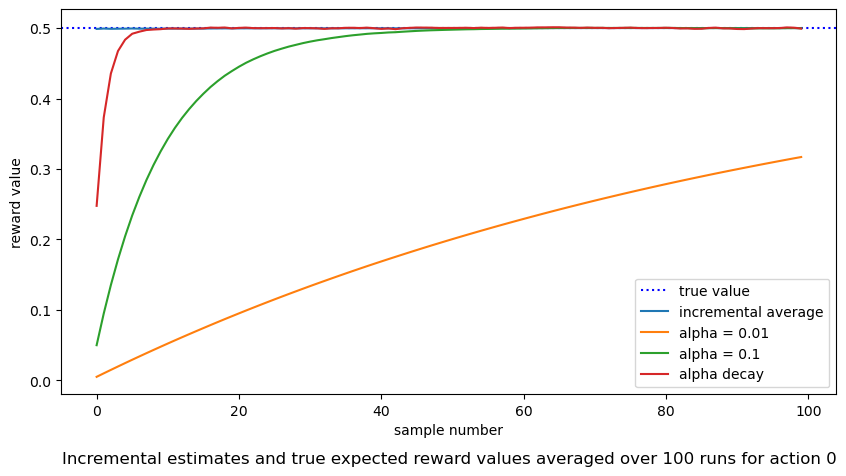

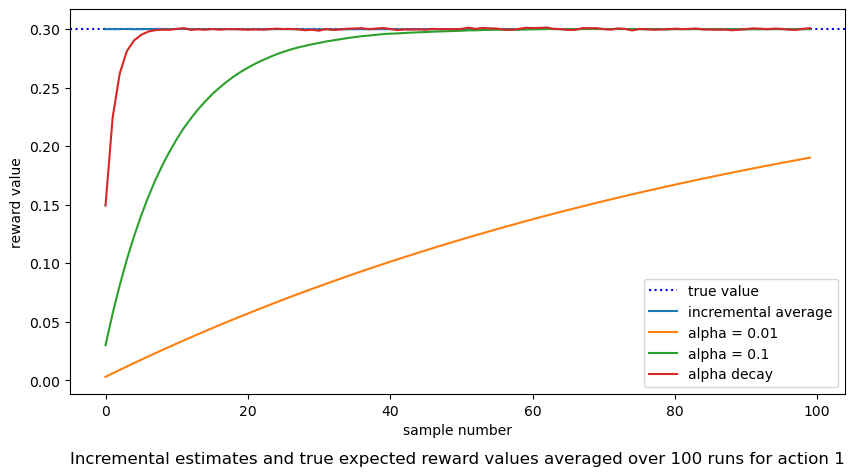

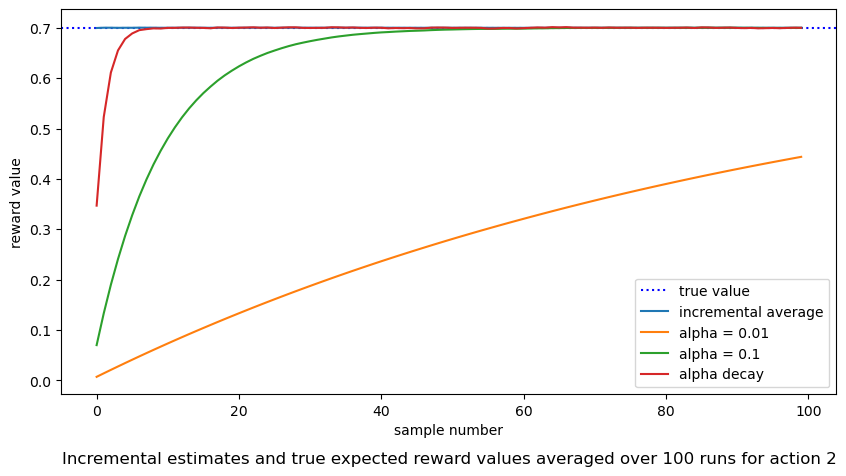

In [8]:
for action in actions:
  fig, ax = plt.subplots()

  # obtain averaged incremental reward values for averaging, alpha = 0.01, alpha = 0.1 and decay alpha over 100 runs
  # TODO:
  mean_incr_avgs_by_actions = np.mean(incr_avgs_runs[:,action], axis=0)
  mean_alpha_1_percent_by_actions = np.mean(alpha_1_percent_runs[:,action], axis=0)
  mean_alpha_10_percent_by_actions = np.mean(alpha_10_percent_runs[:,action], axis=0)
  mean_alpha_decay_by_actions = np.mean(alpha_decay_runs[:,action], axis=0)

  true_value = means[action] # true value of the action

  # obtain the standard deviation for averaging, alpha = 0.01, alpha = 0.1 and decay alpha over 100 runs
  std_incr_avgs_by_actions = np.std(incr_avgs_runs[:,action], axis=0)
  std_alpha_1_percent_by_actions = np.std(alpha_1_percent_runs[:,action], axis=0)
  std_alpha_10_percent_by_actions = np.std(alpha_10_percent_runs[:,action], axis=0)
  std_alpha_decay_by_actions = np.std(alpha_decay_runs[:,action], axis=0)

  # obtain the standard error for averaging, alpha = 0.01, alpha = 0.1 and decay alpha over 100 runs
  # Standard error = standard deviation / sqrt(number of runs)
  std_err_incr_avgs_by_actions = std_incr_avgs_by_actions / np.sqrt(100)
  std_err_alpha_1_percent_by_actions = std_alpha_1_percent_by_actions / np.sqrt(100)
  std_err_alpha_10_percent_by_actions = std_alpha_10_percent_by_actions / np.sqrt(100)
  std_err_alpha_decay_by_actions = std_alpha_decay_by_actions / np.sqrt(100)
  
  # draw the true value line
  line_true_val = ax.axhline(y = true_value, color = 'b', linestyle = ':', label = "true value")

  # draw the averaged incremental reward values for averaging
  plt_incr_avgs, = ax.plot(mean_incr_avgs_by_actions, label = "incremental average")
  # draw the error bar/area for averaging
  incr_avgs_minus_std_err = mean_incr_avgs_by_actions - std_err_incr_avgs_by_actions
  incr_avgs_plus_std_err = mean_incr_avgs_by_actions + std_err_incr_avgs_by_actions
  ax.fill_between(range(0,100), incr_avgs_minus_std_err, incr_avgs_plus_std_err, alpha=0.3)

  # draw the averaged incremental reward values for alpha = 0.01
  plt_alpha_1_percent, = ax.plot(mean_alpha_1_percent_by_actions, label = "alpha = 0.01")
  # draw the error bar/area for alpha = 0.01
  alpha_1_percent_minus_std_err = mean_alpha_1_percent_by_actions - std_err_alpha_1_percent_by_actions
  alpha_1_percent_plus_std_err = mean_alpha_1_percent_by_actions + std_err_alpha_1_percent_by_actions
  ax.fill_between(range(0,100), alpha_1_percent_minus_std_err, alpha_1_percent_plus_std_err, alpha=0.3)

  # draw the averaged incremental reward values for alpha = 0.1
  plt_alpha_10_percent, = ax.plot(mean_alpha_10_percent_by_actions, label = "alpha = 0.1")
  # draw the error bar/area for alpha = 0.1
  alpha_10_percent_minus_std_err = mean_alpha_10_percent_by_actions - std_err_alpha_10_percent_by_actions
  alpha_10_percent_plus_std_err = mean_alpha_10_percent_by_actions + std_err_alpha_10_percent_by_actions
  ax.fill_between(range(0,100), alpha_10_percent_minus_std_err, alpha_10_percent_plus_std_err, alpha=0.3)
  
  plt_alpha_decay, = ax.plot(mean_alpha_decay_by_actions, label = "alpha decay")
  alpha_decay_minus_std_err = mean_alpha_decay_by_actions - std_err_alpha_decay_by_actions
  alpha_decay_plus_std_err = mean_alpha_decay_by_actions + std_err_alpha_decay_by_actions
  ax.fill_between(range(0,100), alpha_decay_minus_std_err, alpha_decay_plus_std_err, alpha=0.3)

  ax.set_xlabel("sample number")
  ax.set_ylabel("reward value")
  ax.set_title("Incremental estimates and true expected reward values averaged over 100 runs for action %s" %action, y=-0.2)

  ax.legend(handles=[line_true_val, plt_incr_avgs, plt_alpha_1_percent, plt_alpha_10_percent, plt_alpha_decay])

### Answers

<b><u> Explain in 1-2 sentences what you observe.</u></b>

In general, as the sample number increases, the reward value approaches the true distribution's mean at different rates depending on the learning rate / averaging method. Incremental Averaging performs the best as the initial reward value is immediately near the true reward value and changes very little over successive samples. The learning rate based methods change more significantly from their starting point, with increasing alpha values converging faster, however decaying alpha converges the fastest.

<b><u>Which of the $\alpha$ values perform better?</u></b>

The $\alpha = 0.1$ method performs the best as it converges to the true action reward value faster and starts from a superior initial point.

<b><u> How do these methods compare to the incremental averaging and decaying learning rate?</u></b>

The constant $\alpha$ methods are outperformed by both the incremental averaging and decaying learning rate methods as the latter two converge to the true mean significantly faster than the former.

<b><u> When is it beneficial to use a decaying learning rate? </u></b>

A decaying learning rate is best used when fast initial learning combined with stability later in the learning process is desired. This essentially translates to fast convergence early on followed by slower, more stable convergence later in the training.

<b><u> If you wanted to optimize further, what range of $\alpha$ would you choose? </u></b>

Since an $\alpha$ of 0.1 outperformed 0.01, values in the range of [0.1, 0.3] could be investigated as this balances faster convergence rates than 0.1 and the risk of overshooting and divergence.


## Q4 Epsilon-greedy

In [20]:
def epsilon_greedy(bandit, epsilon, alpha = None, num_time_step = 1000, epsilon_decay=False, lambda_=0.001):
  """Epsilon greedy algorithm for bandit action selection

  Parameters
  ----------
  bandit : bandit class
      A gaussian bandit 
  epsilon: float
      A parameter which determines the probability for a random action to be selected
  alpha: (optional) float
      A parameter which determined the learning rate for averaging. If alpha is none, incremental averaging is used.
      Default is none, corresponding to incremental averaging.

  Returns
  -------
  R_over_t
      a list of instantaneous return over the time steps
  total_R_over_t
      a list of cummulative reward over the time steps
  est_is_best_over_t
      a list of values of 0 and 1 where 1 indicates the estimated best action is the true best action and 0 otherwise for each time step
  l_over_t
      a list of instanteneous regret over the time steps
  total_l_over_t
      a list of cummulative regret over the time steps
  """
  # TODO:
  num_arms = bandit.num_arms

  Q_arr = np.zeros(num_arms) # action value estimates
  N_arr = np.zeros(num_arms) # number of times each action was selected
  total_R = 0
  total_l = 0
  actions = range(num_arms)

  opt_value = np.max(bandit.mean)
  best_action = np.argmax(bandit.mean)

  R_over_t = []
  total_R_over_t = []
  est_is_best_over_t = []
  l_over_t = []
  total_l_over_t = []
  
  epsilon_t = epsilon 

  for time_step in range(num_time_step):
    if epsilon_decay:
        epsilon_t = epsilon / (1 + lambda_ * time_step)
      
    A_star = np.argmax(Q_arr) # epsilon greedy action selection  
    A_random = actions[np.random.choice(actions)] # random action selection
    A = np.random.choice([A_star, A_random], p=[1-epsilon_t, epsilon_t]) # either pick the greedy action or the random (epsilon) action
    curr_R = bandit.sample(A) # sample reward from the selected action
    N_arr[A] = N_arr[A] + 1 # increment the number of times the action was selected

    if alpha == None:
      # incremental averaging
      Q_arr[A] = Q_arr[A] + (1/N_arr[A]) * (curr_R - Q_arr[A])
    else:
      Q_arr[A] = Q_arr[A] + alpha * (curr_R - Q_arr[A])

    R_over_t.append(curr_R)

    total_R = np.sum(R_over_t)
    total_R_over_t.append(total_R)

    # estimate the best action, if multiple actions have the maxiumum value, select randomly among them
    # est_is_best = np.random.choice([1, 0], p=[1 - epsilon_t, epsilon_t]) if np.argmax(Q_arr) == best_action else 0
    est_is_best = 1 if np.argmax(Q_arr) == best_action else 0
    est_is_best_over_t.append(est_is_best)

    # instantaneous regret
    l_t = opt_value - curr_R
    l_over_t.append(l_t)

    total_l = np.sum(l_over_t)
    total_l_over_t.append(total_l)

  return R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t


### Graphs

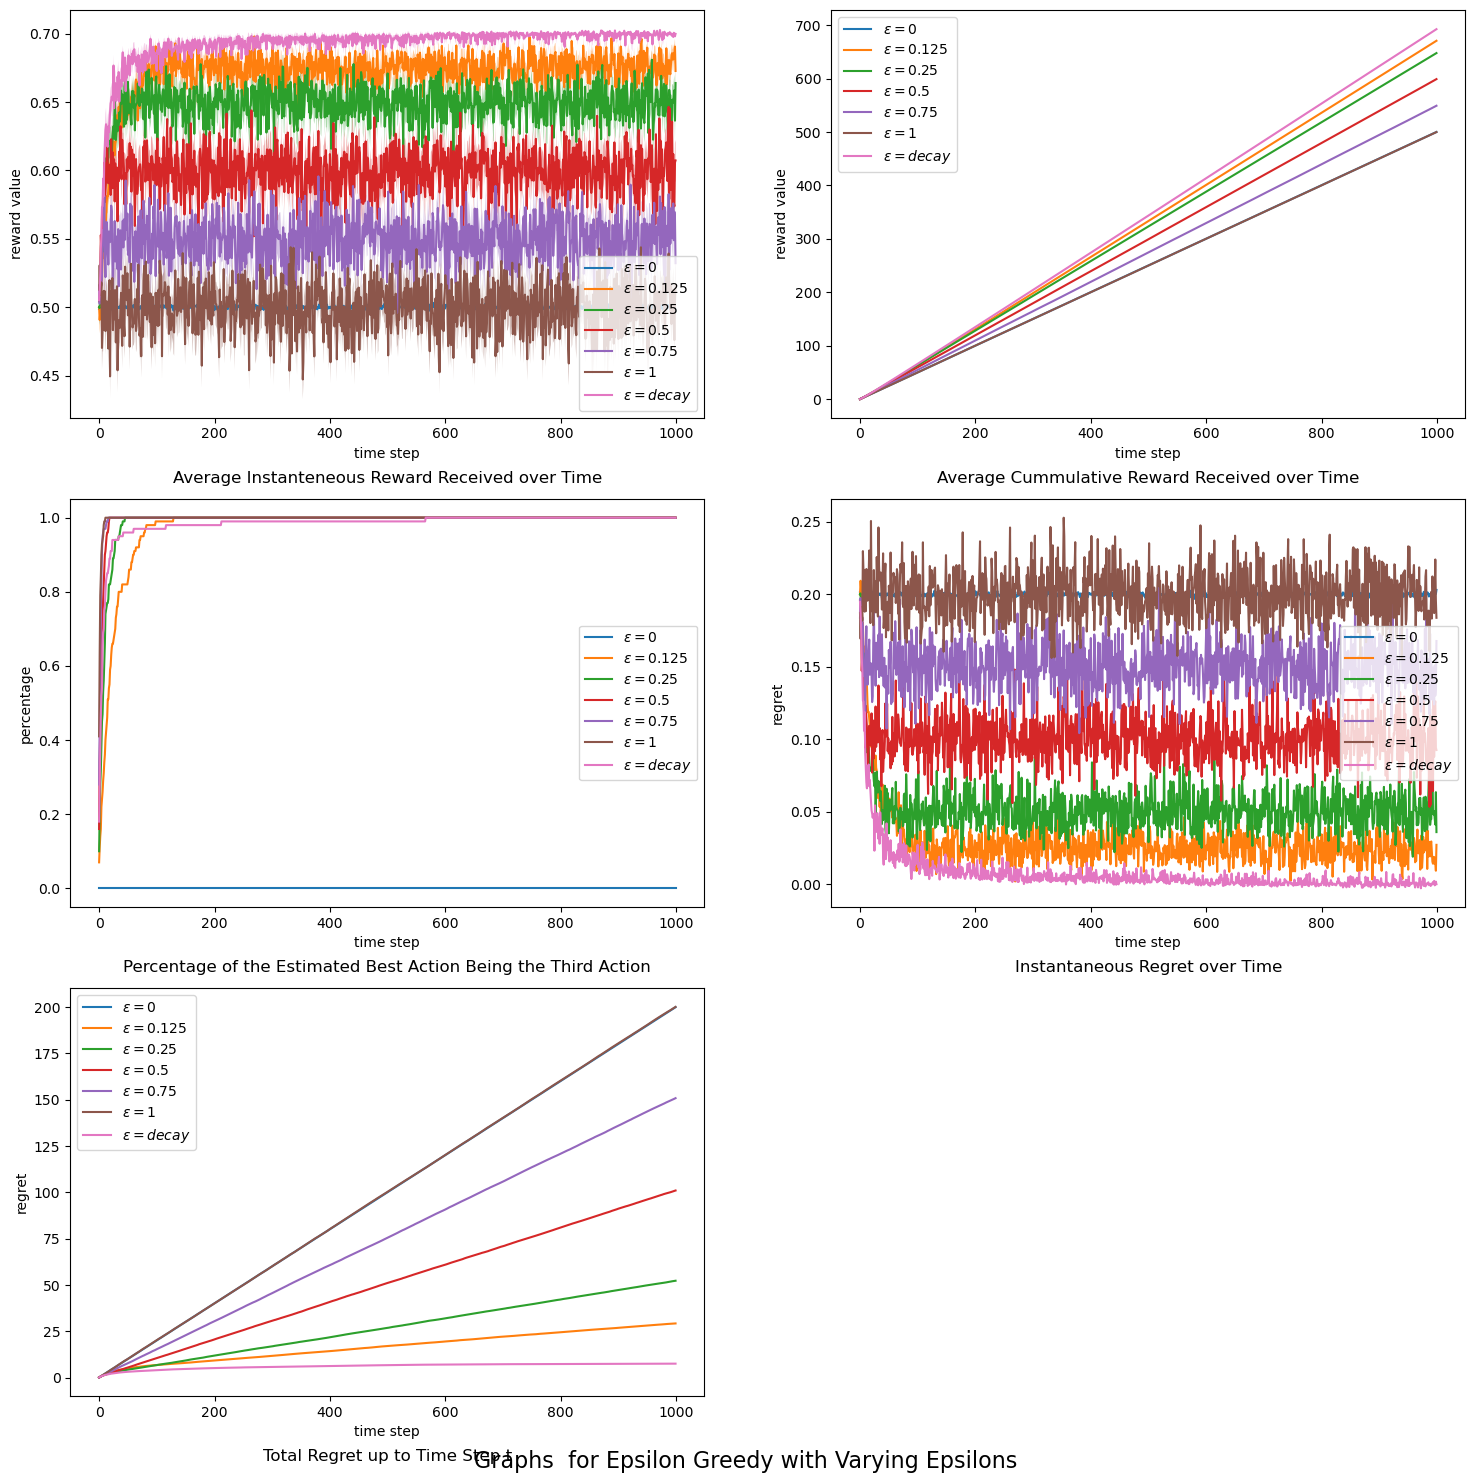

In [21]:
#TODO:
epsilons = [0, 0.125, 0.25, 0.5, 0.75, 1]
decaying_epsilon_params = {'epsilon_0': 0.5, 'lambda_': 0.1}  # Decaying epsilon parameters

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))

for epsilon in epsilons + ["decay"]:

  # arrays of the data generated from 100 runs
  R_over_t_runs = []
  total_R_over_t_runs = []
  est_is_best_over_t_runs = []
  l_over_t_runs = []
  total_l_over_t_runs = []

  for run in range(100):
    if epsilon == "decay":
      R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t = epsilon_greedy(
          three_arm_gaussian_bandit, 
          decaying_epsilon_params['epsilon_0'], 
          epsilon_decay=True, 
          lambda_=decaying_epsilon_params['lambda_']
      )
    else:
      R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t = epsilon_greedy(
          three_arm_gaussian_bandit, 
          epsilon
      )
    R_over_t_runs.append(R_over_t)
    total_R_over_t_runs.append(total_R_over_t)
    est_is_best_over_t_runs.append(est_is_best_over_t)
    l_over_t_runs.append(l_over_t)
    total_l_over_t_runs.append(total_l_over_t)

  R_over_t_runs = np.asarray(R_over_t_runs)
  total_R_over_t_runs = np.asarray(total_R_over_t_runs)
  est_is_best_over_t_runs = np.asarray(est_is_best_over_t_runs)
  l_over_t_runs = np.asarray(l_over_t_runs)
  total_l_over_t_runs = np.asarray(total_l_over_t_runs)

  # plot the mean reward over time

  mean_R_over_t_runs = np.mean(R_over_t_runs, axis=0)
  std_err_R_over_t_runs = np.std(R_over_t_runs, axis=0) / np.sqrt(np.size(R_over_t_runs, axis=0))

  axs[0,0].plot(mean_R_over_t_runs, label = r"$\epsilon = %s$" %epsilon)

  R_over_t_minus_std_err = mean_R_over_t_runs - std_err_R_over_t_runs
  R_over_t_plus_std_err = mean_R_over_t_runs  + std_err_R_over_t_runs
  axs[0,0].fill_between(range(0,1000), R_over_t_minus_std_err, R_over_t_plus_std_err, alpha=0.4)
  # axs[0,0].errorbar(range(0,1000), mean_R_over_t_runs, yerr=std_err_R_over_t_runs)

  axs[0,0].legend()
  axs[0,0].set_xlabel("time step")
  axs[0,0].set_ylabel("reward value")
  axs[0,0].set_title("Average Instanteneous Reward Received over Time", y=-0.18)

  # plot the mean cummulative reward over time

  mean_total_R_over_t_runs = np.mean(total_R_over_t_runs, axis=0)
  std_err_total_R_over_t_runs = np.std(total_R_over_t_runs, axis=0) / np.sqrt(np.size(total_R_over_t_runs, axis=0))

  axs[0,1].plot(mean_total_R_over_t_runs, label = r"$\epsilon = %s$" %epsilon)

  total_R_over_t_minus_std_err = mean_total_R_over_t_runs - std_err_total_R_over_t_runs
  total_R_over_t_plus_std_err = mean_total_R_over_t_runs  + std_err_total_R_over_t_runs
  axs[0,1].fill_between(range(0,1000), total_R_over_t_minus_std_err, total_R_over_t_plus_std_err, alpha=0.4)

  axs[0,1].legend()
  axs[0,1].set_xlabel("time step")
  axs[0,1].set_ylabel("reward value")
  axs[0,1].set_title("Average Cummulative Reward Received over Time", y=-0.18)

  #plot the mean percentage of the estimated best action being the first action

  est_is_best_over_t_runs_avgs = np.mean(est_is_best_over_t_runs, axis=0)
  plt_est_is_best_over_t_runs_avgs, = axs[1,0].plot(est_is_best_over_t_runs_avgs, label = r"$\epsilon = %s$" %epsilon)

  axs[1,0].legend()
  axs[1,0].set_xlabel("time step")
  axs[1,0].set_ylabel("percentage")
  axs[1,0].set_title("Percentage of the Estimated Best Action Being the Third Action", y=-0.18)

  #plot the mean instantaneous regret over time

  l_over_t_runs_avgs = np.mean(l_over_t_runs, axis=0)
  axs[1,1].plot(l_over_t_runs_avgs, label = r"$\epsilon = %s$" %epsilon)

  axs[1,1].legend()
  axs[1,1].set_xlabel("time step")
  axs[1,1].set_ylabel("regret")
  axs[1,1].set_title("Instantaneous Regret over Time", y=-0.18)

  #plot the total regret over time

  total_l_over_t_runs_avgs = np.mean(total_l_over_t_runs, axis=0)
  axs[2,0].plot(total_l_over_t_runs_avgs, label = r"$\epsilon = %s$" %epsilon)

  axs[2,0].legend()
  axs[2,0].set_xlabel("time step")
  axs[2,0].set_ylabel("regret")
  axs[2,0].set_title("Total Regret up to Time Step t", y=-0.18)

axs[-1, -1].axis('off')

title = r'Graphs  for Epsilon Greedy with Varying Epsilons'
fig.suptitle(title, fontsize=16, y=0.08)

plt.show()

### Answers

<b><u> Explain what you observe in the graphs and discuss the effect of $\epsilon$, including decaying $\epsilon$ </b></u>

Across each of the graphs generated, there is a distinct trend with varying $\epsilon$ values, while $\epsilon$ decay performs the best. As the $\epsilon$ value decreases from 3/4 to 1/8, performance increases with regard to the instantaneous reward, regret and percentage of the time the true best (third) action is chosen, where 3/4 performs poorly and 1/8 performs the best out of the constant $\epsilon$ methods. The $\epsilon = 1$ and $\epsilon = 0$ case  are two extremes, showcasing the difference between pure exploration and pure exploitation, respectively. Finally, Each of the cumulative (total) reward and regret curves generally agree with theoretical growth characteristics.

In the average instantaneous reward plot, small or moderate $\epsilon$ values (e.g. 0.125 or 0.25) converge to a higher reward because they explore enough initially before exploiting the best arm once found. Conversely, extremely high $\epsilon$ (0.75 and 1.0) lead to the agent exploring suboptimal arms too frequently, resulting in its average reward remaining lower over all time steps and having larger fluctuations due to the higher stochastic effect. Meanwhile, the purely greedy strategy ($\epsilon = 0$) does very poorly as it starts on a non-optimal arm and does not explore alternatives, resulting in relatively constant behaviour. It is possible that with a differnt random seed, this policy could do very well if it happens upon the best arm early, though this is pure luck. Decaying $\epsilon$ starts high (lots of exploration) but shrinks over time, so that eventually it behaves more greedily yielding the highest long‐term reward, effectively avoiding permanent random exploration. The average cumulative reward plot grows fastest when the agent settles on the best arm quickly and remains there, with the steepest curves indicating the best performance. Again, $\epsilon$ = 0.125 and decaying $\epsilon$ perform the best, both growing linearly with the steepest slope. By contrast, the policy over-exploration ($\epsilon$ = 0.75-1$) and pure exploitation ($\epsilon$ = 0) strategies result in the slowest cumulative reward growth.

Regret, both instantaneously and cumulatively, reflects the difference between actually chosen arms and the true best arm. Frequent exploration leads to higher regret at each step, while too little exploration means the agent may never switch from a bad guess. Better $\epsilon$-values, such as 0.125, reduce the long-term regret by finding and consistently chooses the best arm. Consequently, the instantaneous regret for the well-balanced or decaying $\epsilon$-strategies exhibit the fastest drop compared to extreme $\epsilon$-settings. Meanwhile, in the total curves, constant $\epsilon$-strategies result in linear regret, with lower $\epsilon$-values performing better showcased by their shallower slopes ($\epsilon$ = 1 or 0 worst, $\epsilon$ = 0.125 best). Decaying $\epsilon$ total regret behaves sublinearly, out-performing all the other methods.

## Q5 Hyperparameters for Epsilon-greedy

To have a plain start, you have been provided with predefined functions for generating plots until now. However, moving forward, you are expected to plot graphs on your own.

### Graphs

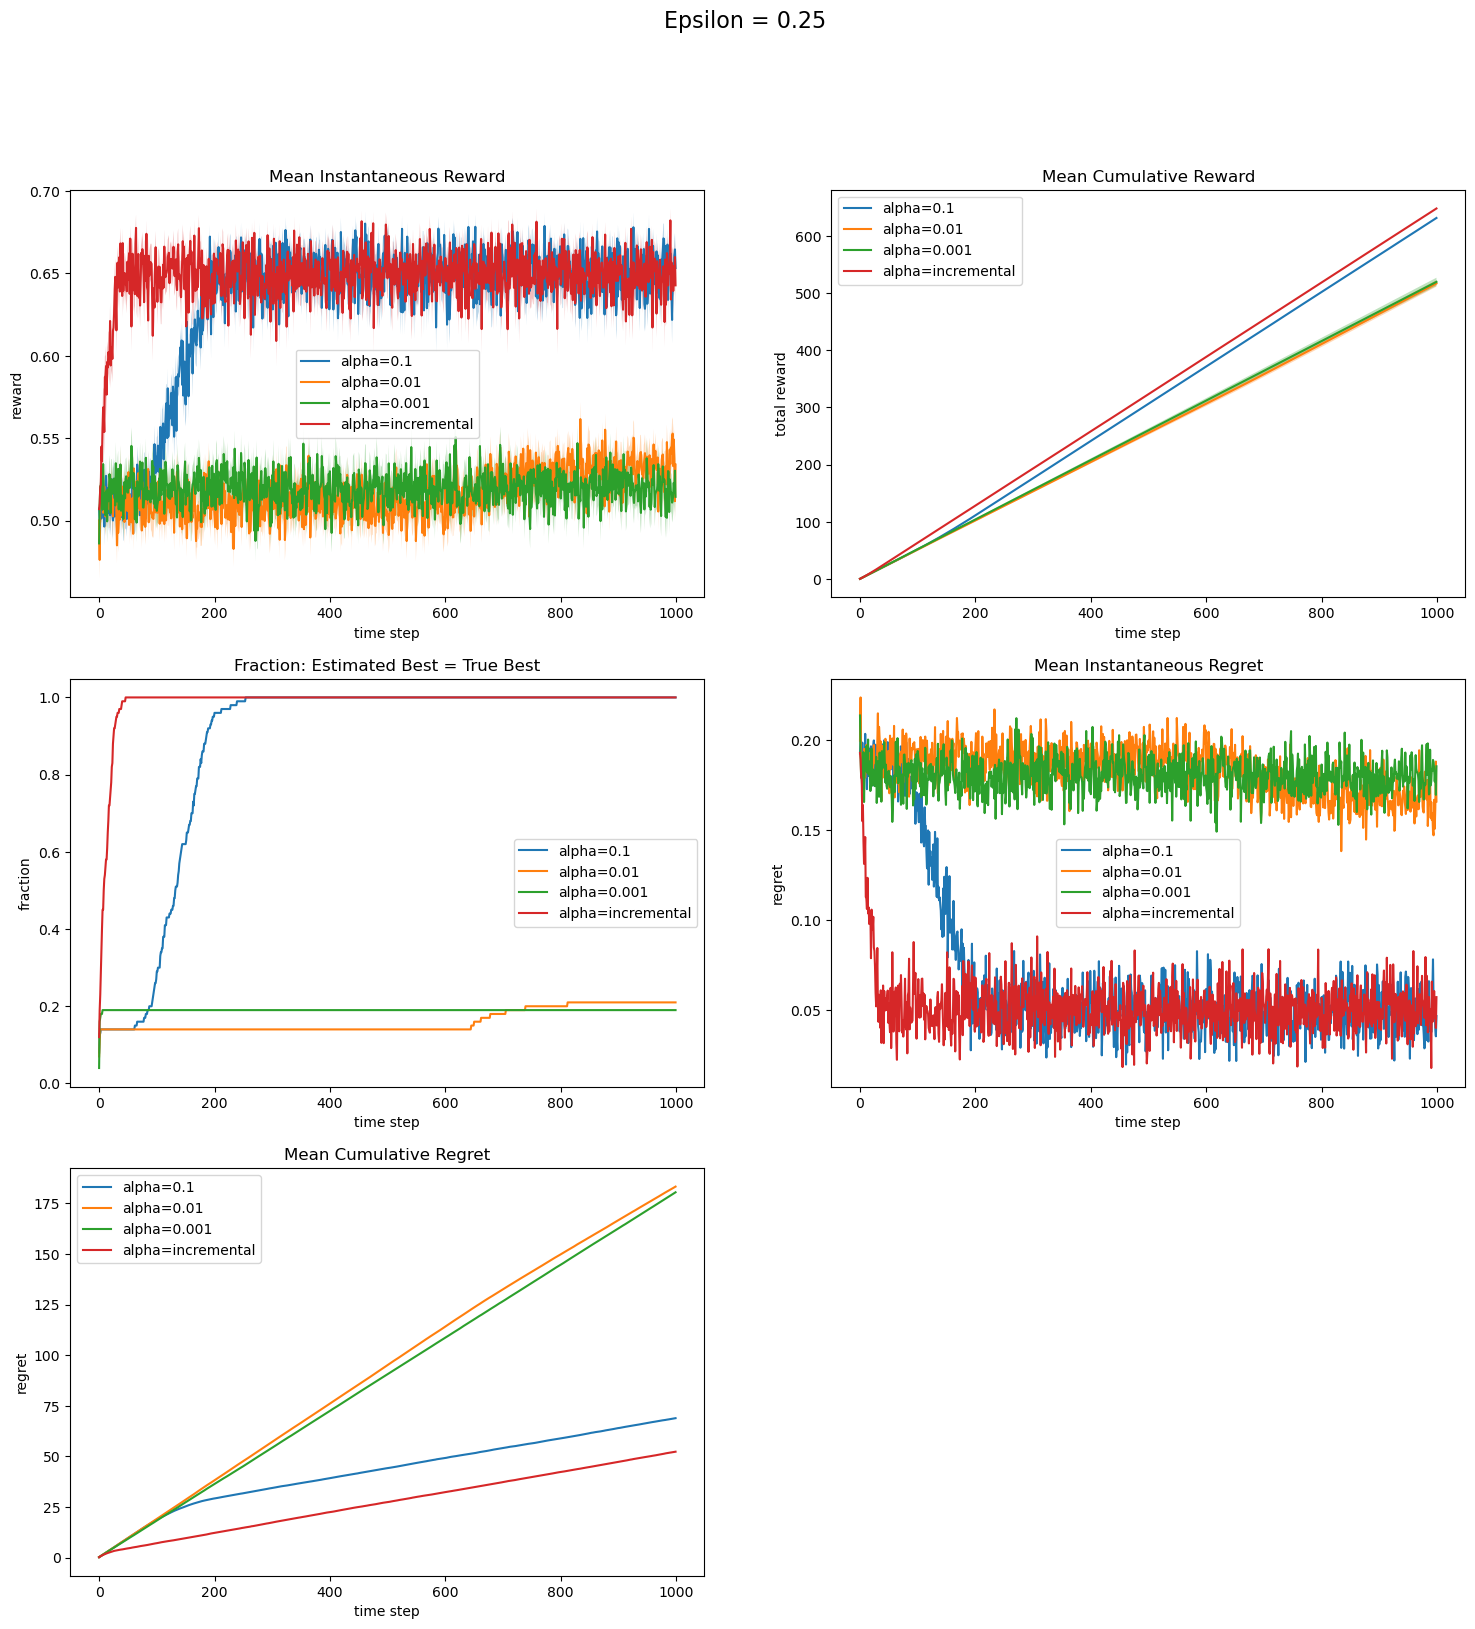

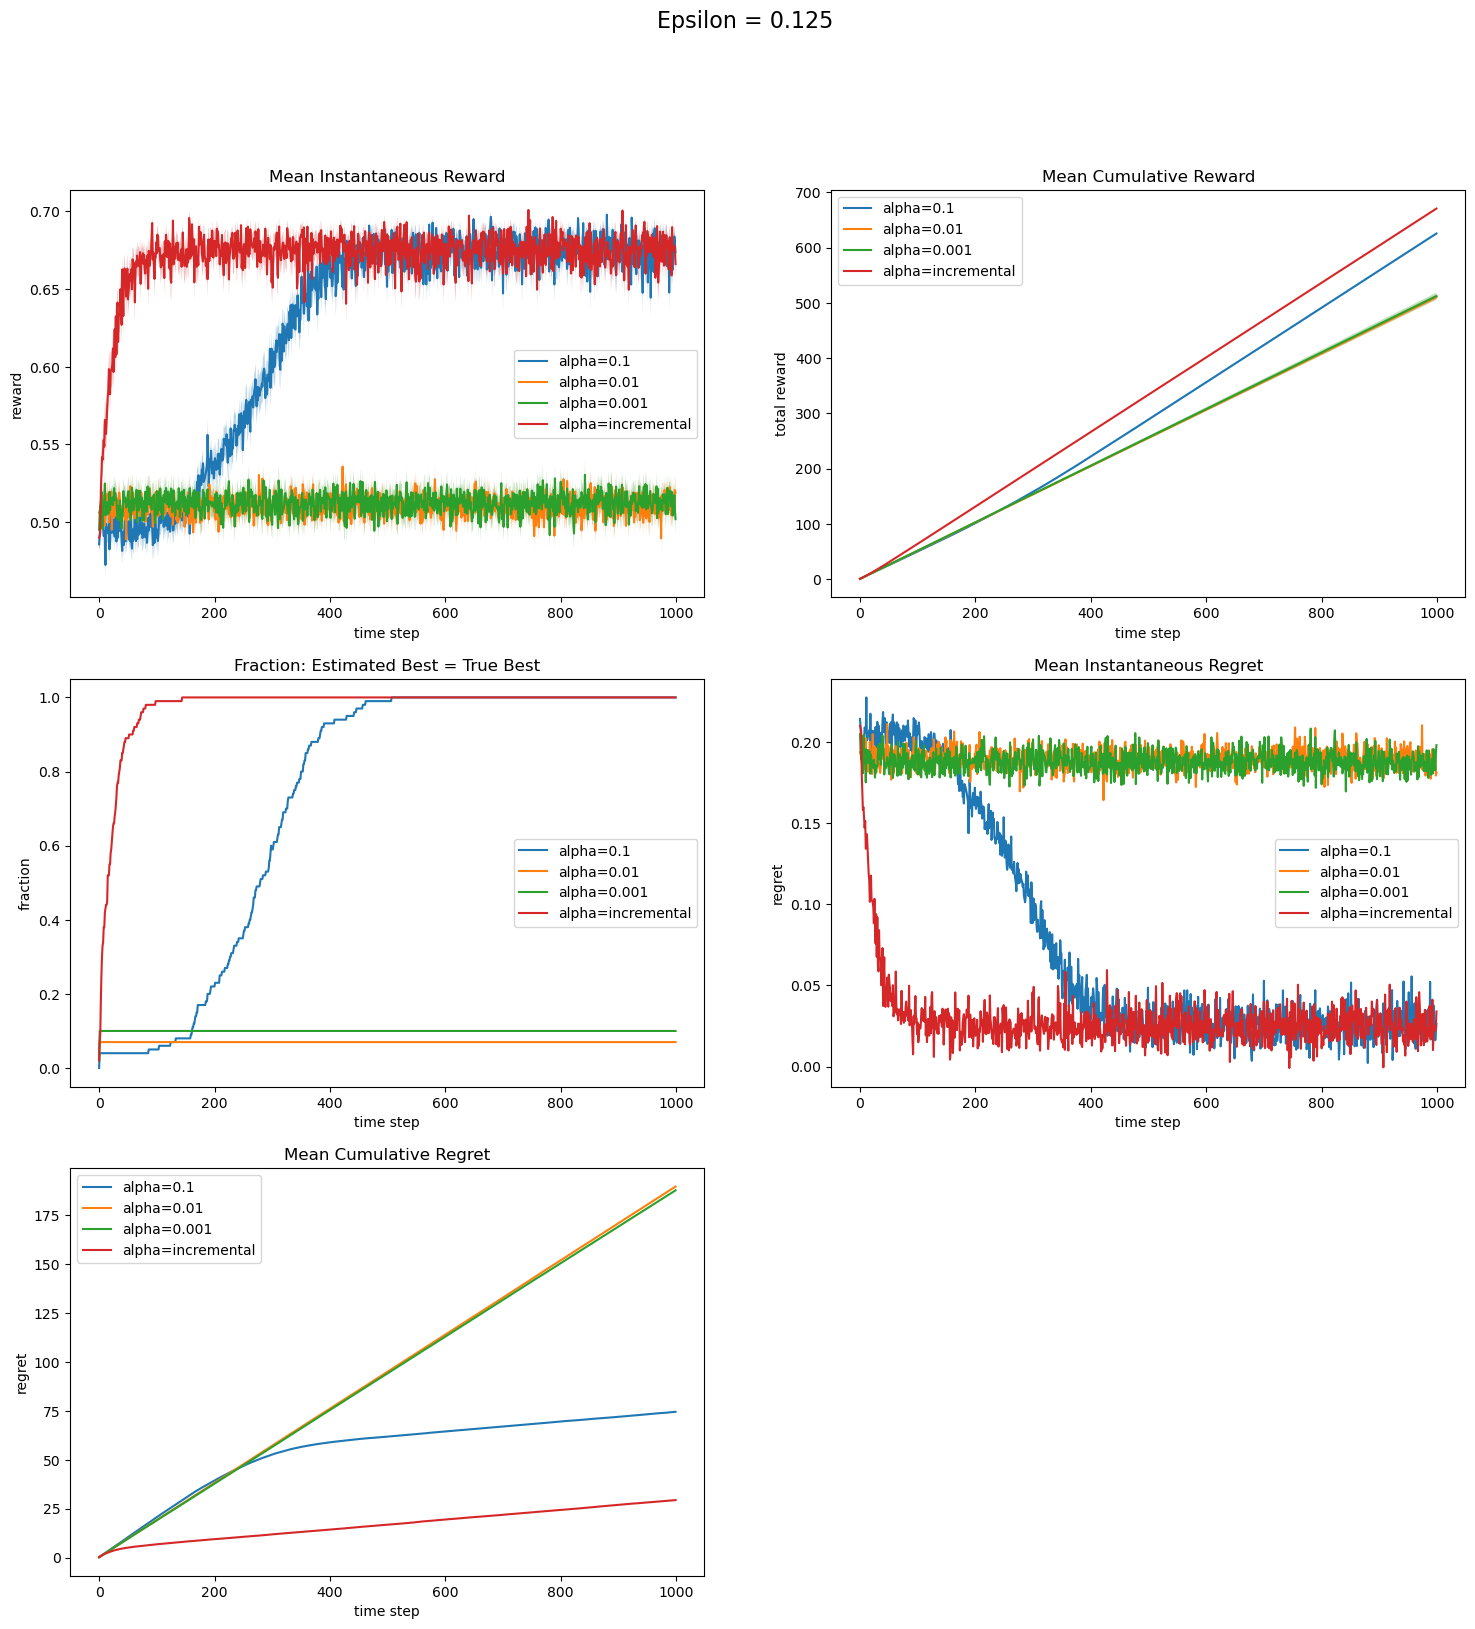

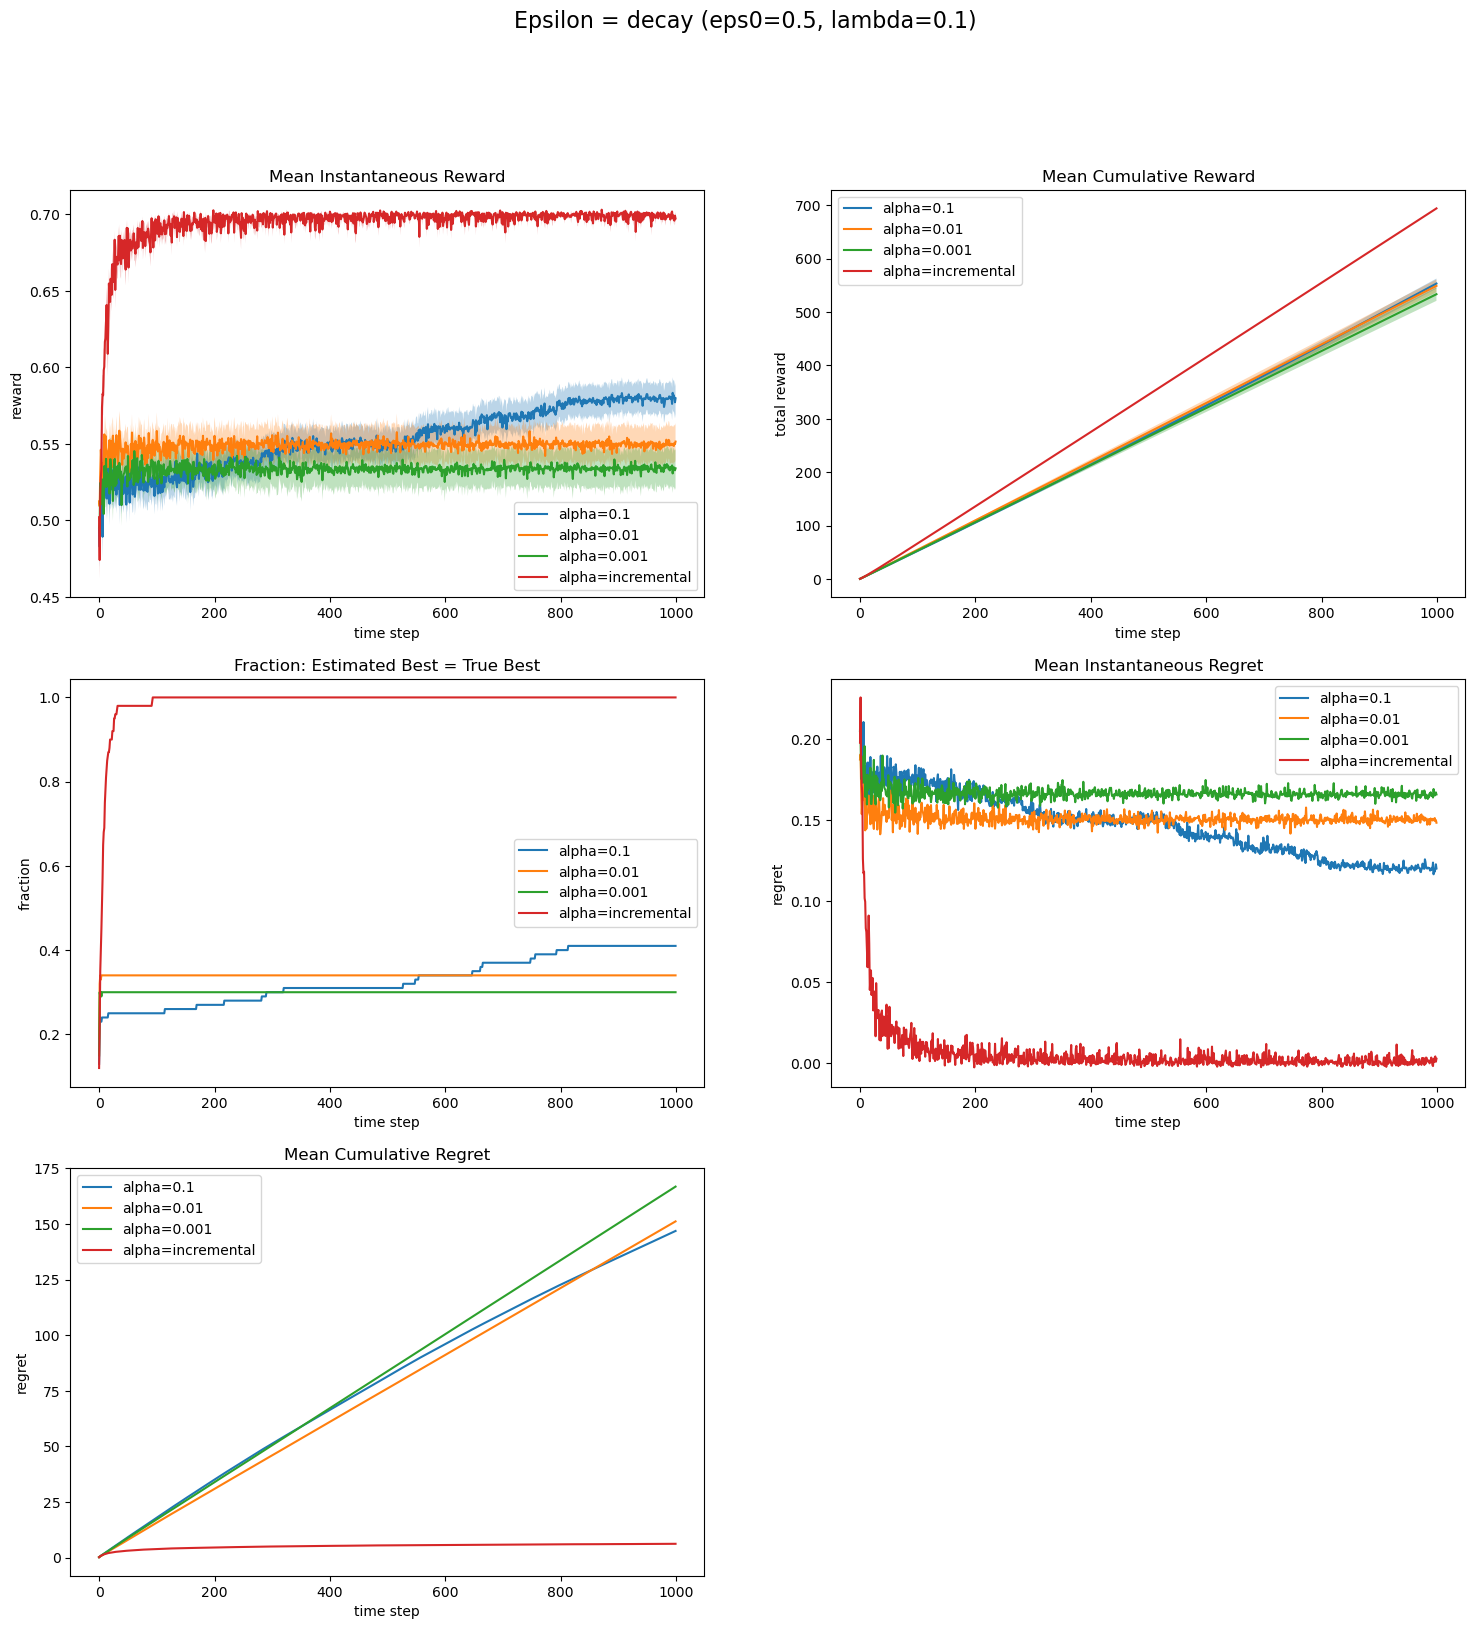

In [30]:
alphas = [0.1, 0.01, 0.001, None]

epsilons = [0.25, 0.125, "decay"]

# decay parameters
epsilon_0_for_decay = 0.5
lambda_for_decay = 0.1

T = 1000
num_runs = 100

for eps in epsilons:
    # create a figure for this epsilon
    fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))

    # fig title
    if eps == "decay":
        eps_label = f"decay (eps0={epsilon_0_for_decay}, lambda={lambda_for_decay})"
    else:
        eps_label = str(eps)

    # loop over the alpha settings
    for alpha_setting in alphas:

        R_over_t_runs           = []
        total_R_over_t_runs     = []
        est_is_best_over_t_runs = []
        l_over_t_runs           = []
        total_l_over_t_runs     = []

        for run in range(num_runs):
            if eps == "decay":
                R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t = epsilon_greedy(
                    three_arm_gaussian_bandit,
                    epsilon=epsilon_0_for_decay,
                    alpha=alpha_setting,
                    num_time_step=T,
                    epsilon_decay=True,
                    lambda_=lambda_for_decay
                )
            else:
                R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t = epsilon_greedy(
                    three_arm_gaussian_bandit,
                    epsilon=eps,
                    alpha=alpha_setting,
                    num_time_step=T,
                    epsilon_decay=False,
                    lambda_=0.0
                )
            R_over_t_runs.append(R_over_t)
            total_R_over_t_runs.append(total_R_over_t)
            est_is_best_over_t_runs.append(est_is_best_over_t)
            l_over_t_runs.append(l_over_t)
            total_l_over_t_runs.append(total_l_over_t)

        # convert to np arrays
        R_over_t_runs           = np.array(R_over_t_runs)
        total_R_over_t_runs     = np.array(total_R_over_t_runs)
        est_is_best_over_t_runs = np.array(est_is_best_over_t_runs)
        l_over_t_runs           = np.array(l_over_t_runs)
        total_l_over_t_runs     = np.array(total_l_over_t_runs)

        # compute statistics
        mean_R          = np.mean(R_over_t_runs, axis=0)
        std_err_R       = np.std(R_over_t_runs, axis=0) / np.sqrt(num_runs)
        mean_total_R    = np.mean(total_R_over_t_runs, axis=0)
        std_err_total_R = np.std(total_R_over_t_runs, axis=0) / np.sqrt(num_runs)
        mean_est_best   = np.mean(est_is_best_over_t_runs, axis=0)
        mean_l          = np.mean(l_over_t_runs, axis=0)
        mean_total_l    = np.mean(total_l_over_t_runs, axis=0)

        # build legend
        if alpha_setting is None:
            alpha_label = "incremental"
        else:
            alpha_label = str(alpha_setting)

        # mean instantaneous reward
        axs[0,0].plot(mean_R, label=f"alpha={alpha_label}")
        axs[0,0].fill_between(
            np.arange(T),
            mean_R - std_err_R,
            mean_R + std_err_R,
            alpha=0.3
        )
        axs[0,0].set_title("Mean Instantaneous Reward")
        axs[0,0].set_xlabel("time step")
        axs[0,0].set_ylabel("reward")
        axs[0,0].legend()

        # mean cumulative reward
        axs[0,1].plot(mean_total_R, label=f"alpha={alpha_label}")
        axs[0,1].fill_between(
            np.arange(T),
            mean_total_R - std_err_total_R,
            mean_total_R + std_err_total_R,
            alpha=0.3
        )
        axs[0,1].set_title("Mean Cumulative Reward")
        axs[0,1].set_xlabel("time step")
        axs[0,1].set_ylabel("total reward")
        axs[0,1].legend()

        # probability that estimated best action = true best
        axs[1,0].plot(mean_est_best, label=f"alpha={alpha_label}")
        axs[1,0].set_title("Fraction: Estimated Best = True Best")
        axs[1,0].set_xlabel("time step")
        axs[1,0].set_ylabel("fraction")
        axs[1,0].legend()

        # mean instantaneous regret
        axs[1,1].plot(mean_l, label=f"alpha={alpha_label}")
        axs[1,1].set_title("Mean Instantaneous Regret")
        axs[1,1].set_xlabel("time step")
        axs[1,1].set_ylabel("regret")
        axs[1,1].legend()

        # mean cumulative regret
        axs[2,0].plot(mean_total_l, label=f"alpha={alpha_label}")
        axs[2,0].set_title("Mean Cumulative Regret")
        axs[2,0].set_xlabel("time step")
        axs[2,0].set_ylabel("regret")
        axs[2,0].legend()

    axs[2,1].axis('off')
    
    fig.suptitle(f"Epsilon = {eps_label}", fontsize=16)
    plt.show()

### Answers

<b><u> Explain in 2-3 sentences what you observe </b></u>

The small $\alpha$ values (0.01, 0.001) show the agent under‐reacting to new feedback and learning more slowly, never fully catching up, as shown by the lower average and instantaneous reward plateau, the shallower cumulative reward curve as well as the higher instantaneous regret plateau and steeper cumulative regret curve. In contrast, $\alpha=0.1$ reacts more strongly to each new reward, so although it starts more slowly, steadily corrects its estimates before eventually surpasses the smaller $\alpha$ curves. Meanwhile, incremental averaging is by far in a way the most effective as more rewards are gathered the estimated mean converges reliably to the arm’s true mean (assuming a stationary bandit) while smoothly transitioning from quick initial learning to increasingly stable estimates.

## Q6 Gradient Bandit

In [14]:
def gradient_bandit(bandit, alpha, num_time_step = 1000, baseline=False, alpha_decay=False, alpha_0=None, lambda_=0.001, p=0.5):
    """
    Gradient bandit algorithm for bandit action selection

    Parameters
    ----------
    bandit : bandit class
        A gaussian bandit 
    alpha: float
        A parameter which determines the learning rate for the action values
    num_time_step: int
        Number of time steps to run the algorithm
    baseline: bool
        A parameter which determines whether to use the average reward as a baseline
    alpha_decay: bool
        A parameter which determines whether to use a decaying learning rate
    alpha_0: float
        A parameter which determines the initial learning rate
    lambda_: float
        A parameter which determines the decay rate constant
    p: float
        A parameter which determines the power parameter for controlling decay
    
    Returns
    -------
    R_over_t
        a list of instantaneous return over the time steps
    total_R_over_t
        a list of cummulative reward over the time steps
    est_is_best_over_t
        a list of values of 0 and 1 where 1 indicates the estimated best action is the true best action and 0 otherwise for each time step
    l_over_t
        a list of instanteneous regret over the time steps
    total_l_over_t
        a list of cummulative regret over the time steps
    """

    num_arms = bandit.num_arms

    H_arr = np.zeros(num_arms) # intialise preference estimates
    
    R_over_t = []
    total_R_over_t = []
    est_is_best_over_t = []
    l_over_t = []
    total_l_over_t = []

    opt_value = np.max(bandit.mean)
    best_action = np.argmax(bandit.mean)

    total_R = 0.0
    total_l = 0.0
    
    # set alpha_0 to alpha if no decay
    if alpha_decay:
        if alpha_0 is None:
            alpha_0 = alpha  # interpret 'alpha' as alpha_0
    else:
        # no decay, so alpha is constant
        alpha_0 = alpha

    for t in range(num_time_step):
        # compute alpha_t (decay or not)
        if alpha_decay:
            alpha_t = alpha_0 / ((1.0 + lambda_ * t)**p)
        else:
            alpha_t = alpha_0  # same every step

        # softmax action selection
        pi_arr = np.exp(H_arr) / np.sum(np.exp(H_arr)) # softmax probabilities
        A = np.random.choice(num_arms, p=pi_arr) # choose action based on softmax probabilities

        # observe reward
        R_t = bandit.sample(A)

        # baseline to normalize rewards
        if baseline and t > 0:
            b_t = np.mean(R_over_t)  # or total_R/(t+1)
        else:
            b_t = 0.0

        # update preferences
        H_arr -= alpha_t * (R_t - b_t) * pi_arr # all arms
        H_arr[A] += alpha_t * (R_t - b_t) # selected arm

        R_over_t.append(R_t)

        total_R += R_t
        total_R_over_t.append(total_R)

        l_t = opt_value - R_t
        l_over_t.append(l_t)

        total_l += l_t
        total_l_over_t.append(total_l)

        # estimate the best action
        if np.argmax(H_arr) == best_action:
            est_is_best = 1
        else:
            est_is_best = 0
        est_is_best_over_t.append(est_is_best)

    return R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t


### Graphs

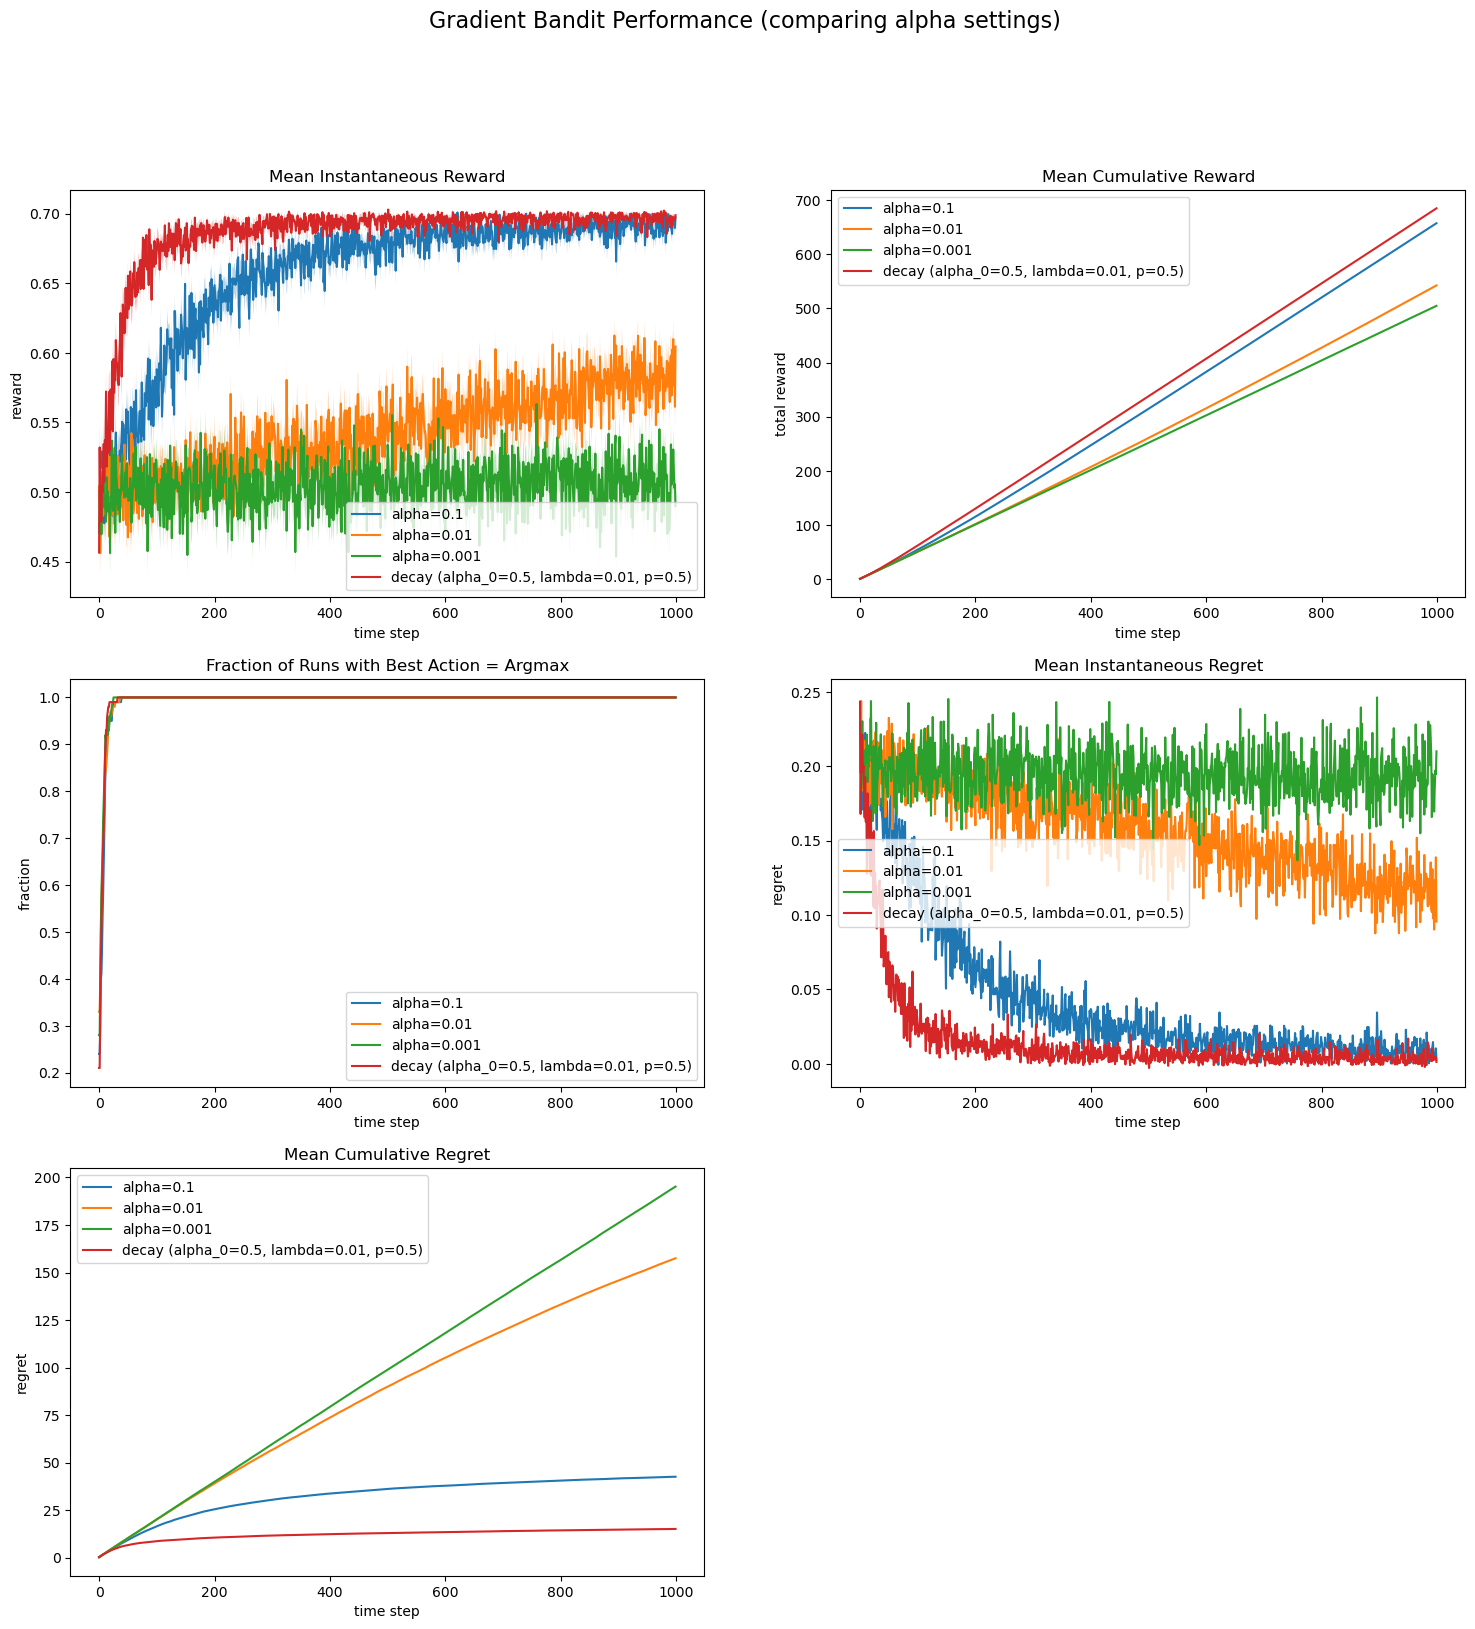

In [15]:
alpha_values = [0.1, 0.01, 0.001, "decay"]

num_runs = 100
T = 1000

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(18,18))

for alpha_setting in alpha_values:

    R_runs          = []
    total_R_runs    = []
    est_best_runs   = []
    l_runs          = []
    total_l_runs    = []

    for run in range(num_runs):

        if alpha_setting == "decay":
            # handle alpha_decay=True, alpha_0=0.5, lambda_=0.01, p=0.5
            R, total_R, est_best, l, total_l = gradient_bandit(
                three_arm_gaussian_bandit,
                alpha=0.5,              # interpret as alpha_0
                alpha_decay=True,
                lambda_=0.01,
                p=0.5,
                num_time_step=T,
                baseline=True           # you can set this to False if desired
            )
        else:
            # fixed alpha
            R, total_R, est_best, l, total_l = gradient_bandit(
                three_arm_gaussian_bandit,
                alpha=alpha_setting,
                alpha_decay=False,
                num_time_step=T,
                baseline=True
            )

        R_runs.append(R)
        total_R_runs.append(total_R)
        est_best_runs.append(est_best)
        l_runs.append(l)
        total_l_runs.append(total_l)

    # convert to np arrays
    R_runs       = np.array(R_runs)
    total_R_runs = np.array(total_R_runs)
    est_best_runs= np.array(est_best_runs)
    l_runs       = np.array(l_runs)
    total_l_runs = np.array(total_l_runs)

    # means and std errors
    mean_R       = np.mean(R_runs, axis=0)
    se_R         = np.std(R_runs, axis=0) / np.sqrt(num_runs)

    mean_total_R = np.mean(total_R_runs, axis=0)
    se_total_R   = np.std(total_R_runs, axis=0)/np.sqrt(num_runs)

    mean_est_best= np.mean(est_best_runs, axis=0)  # fraction that is best
    mean_l       = np.mean(l_runs, axis=0)
    mean_total_l = np.mean(total_l_runs, axis=0)

    # legend label
    if alpha_setting == "decay":
        label_str = "decay (alpha_0=0.5, lambda=0.01, p=0.5)"
    else:
        label_str = f"alpha={alpha_setting}"

    # instantaneous reward
    axs[0,0].plot(mean_R, label=label_str)
    axs[0,0].fill_between(
        np.arange(T),
        mean_R - se_R,
        mean_R + se_R,
        alpha=0.3
    )
    axs[0,0].set_title("Mean Instantaneous Reward")
    axs[0,0].set_xlabel("time step")
    axs[0,0].set_ylabel("reward")
    axs[0,0].legend()

    # mean cumulative reward
    axs[0,1].plot(mean_total_R, label=label_str)
    axs[0,1].fill_between(
        np.arange(T),
        mean_total_R - se_total_R,
        mean_total_R + se_total_R,
        alpha=0.3
    )
    axs[0,1].set_title("Mean Cumulative Reward")
    axs[0,1].set_xlabel("time step")
    axs[0,1].set_ylabel("total reward")
    axs[0,1].legend()

    # probability that best action is chosen
    axs[1,0].plot(mean_est_best, label=label_str)
    axs[1,0].set_title("Fraction of Runs with Best Action = Argmax")
    axs[1,0].set_xlabel("time step")
    axs[1,0].set_ylabel("fraction")
    axs[1,0].legend()

    # instantaneous regret
    axs[1,1].plot(mean_l, label=label_str)
    axs[1,1].set_title("Mean Instantaneous Regret")
    axs[1,1].set_xlabel("time step")
    axs[1,1].set_ylabel("regret")
    axs[1,1].legend()

    # mean cumulative regret
    axs[2,0].plot(mean_total_l, label=label_str)
    axs[2,0].set_title("Mean Cumulative Regret")
    axs[2,0].set_xlabel("time step")
    axs[2,0].set_ylabel("regret")
    axs[2,0].legend()

axs[2,1].axis('off')

plt.suptitle("Gradient Bandit Performance (comparing alpha settings)", fontsize=16)
plt.show()

### Answers

<b><u> Explain briefly what you observe</b></u>

The gradient bandit implementations differ relatively significantly depending on the $\alpha$ values / approach. For constant $\alpha$, as the value increases so to do both the instantaneous and cumulative rewards, highlighting the increase in the responsiveness of the algorithm via preference (H-value) updates. For example, $\alpha = 0.1$ experiences a much faster increase toward the highest instantaneous reward value compared to 0.01 and 0.001, consolidated by its steeper cumulative reward curve. Both regret curves reflect the same behaviour, with the cumulative curve showing a significantly lower regret as t increases. However, the optimal learning rate approach in the gradient bandit implementation is $\alpha$ decay as it shows the best reward and regret performance overall. Since the value of $\alpha_{0}$ is much higher than each of the constant $\alpha$ curves, the change in preference and thus the slope toward high instantaneous rewards is the highest, while the approach also settles on the optimal strategy the fastest due to the decay. In the cumulative reward and regret, the $\alpha$ decay approach shows the steepest increase and fastest sub-linear leveling off of all the methods tested, demonstrating its superiority.

## Q7 Thompson Sampling

In [113]:
def normal_thompson_sampling(bandit, num_time_step = 1000, init_prior_means = None, init_prior_vars = None):
    """
    Thompson sampling algorithm for bandit action selection

    Parameters
    ----------
    bandit : bandit class
        A gaussian bandit 
    num_time_step: int
        Number of time steps to run the algorithm

    Returns
    -------
    R_over_t
        a list of instantaneous return over the time steps
    total_R_over_t
        a list of cummulative reward over the time steps
    est_is_best_over_t
        a list of values of 0 and 1 where 1 indicates the estimated best action is the true best action and 0 otherwise for each time step
    l_over_t
        a list of instanteneous regret over the time steps
    total_l_over_t
        a list of cummulative regret over the time steps
    """

    num_arms = bandit.num_arms

    # default each arm's prior means/vars
    if init_prior_means is None:
        init_prior_means = np.zeros(num_arms)
    if init_prior_vars is None:
        init_prior_vars = np.ones(num_arms)

    # posterior parameters for each arm
    posterior_mean = np.array(init_prior_means, dtype=float)
    posterior_var  = np.array(init_prior_vars, dtype=float)

    total_R = 0.0
    total_l = 0.0

    opt_value = np.max(bandit.mean)
    best_action = np.argmax(bandit.mean)

    R_over_t = []
    total_R_over_t = []
    est_is_best_over_t = []
    l_over_t = []
    total_l_over_t = []

    for t in range(num_time_step):
        # sample a candidate mean from the normal posterior distribution
        samples = np.random.normal(
            loc=posterior_mean,
            scale=np.sqrt(posterior_var)
        )

        # select arm with highest sample
        A = np.argmax(samples)

        # observe reward
        curr_R = bandit.sample(A)

        # update posterior for chosen arm A
        # assume the bandit's true variance is 1.0
        old_var  = posterior_var[A]
        old_mean = posterior_mean[A]

        # posterior variance = 1 / (1/old_var + 1/1.0)
        new_var = 1.0 / (1.0 / old_var + 1.0)
        # posterior mean = new_var * (old_mean/old_var + R/1.0)
        new_mean = new_var * (old_mean / old_var + curr_R)

        posterior_var[A]  = new_var
        posterior_mean[A] = new_mean

        # reward
        R_over_t.append(curr_R)
        total_R += curr_R
        total_R_over_t.append(total_R)

        # regret
        l_t = opt_value - curr_R
        l_over_t.append(l_t)

        total_l += l_t
        total_l_over_t.append(total_l)

        # estimate the best action
        est_best = np.argmax(posterior_mean)
        est_is_best = 1 if est_best == best_action else 0
        est_is_best_over_t.append(est_is_best)

    return R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t


### Graphs

/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_58482/3138274036.py:69: RuntimeWarning: divide by zero encountered in double_scalars
  new_var = 1.0 / (1.0 / old_var + 1.0)
/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_58482/3138274036.py:71: RuntimeWarning: divide by zero encountered in double_scalars
  new_mean = new_var * (old_mean / old_var + curr_R)
/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_58482/3138274036.py:71: RuntimeWarning: invalid value encountered in double_scalars
  new_mean = new_var * (old_mean / old_var + curr_R)


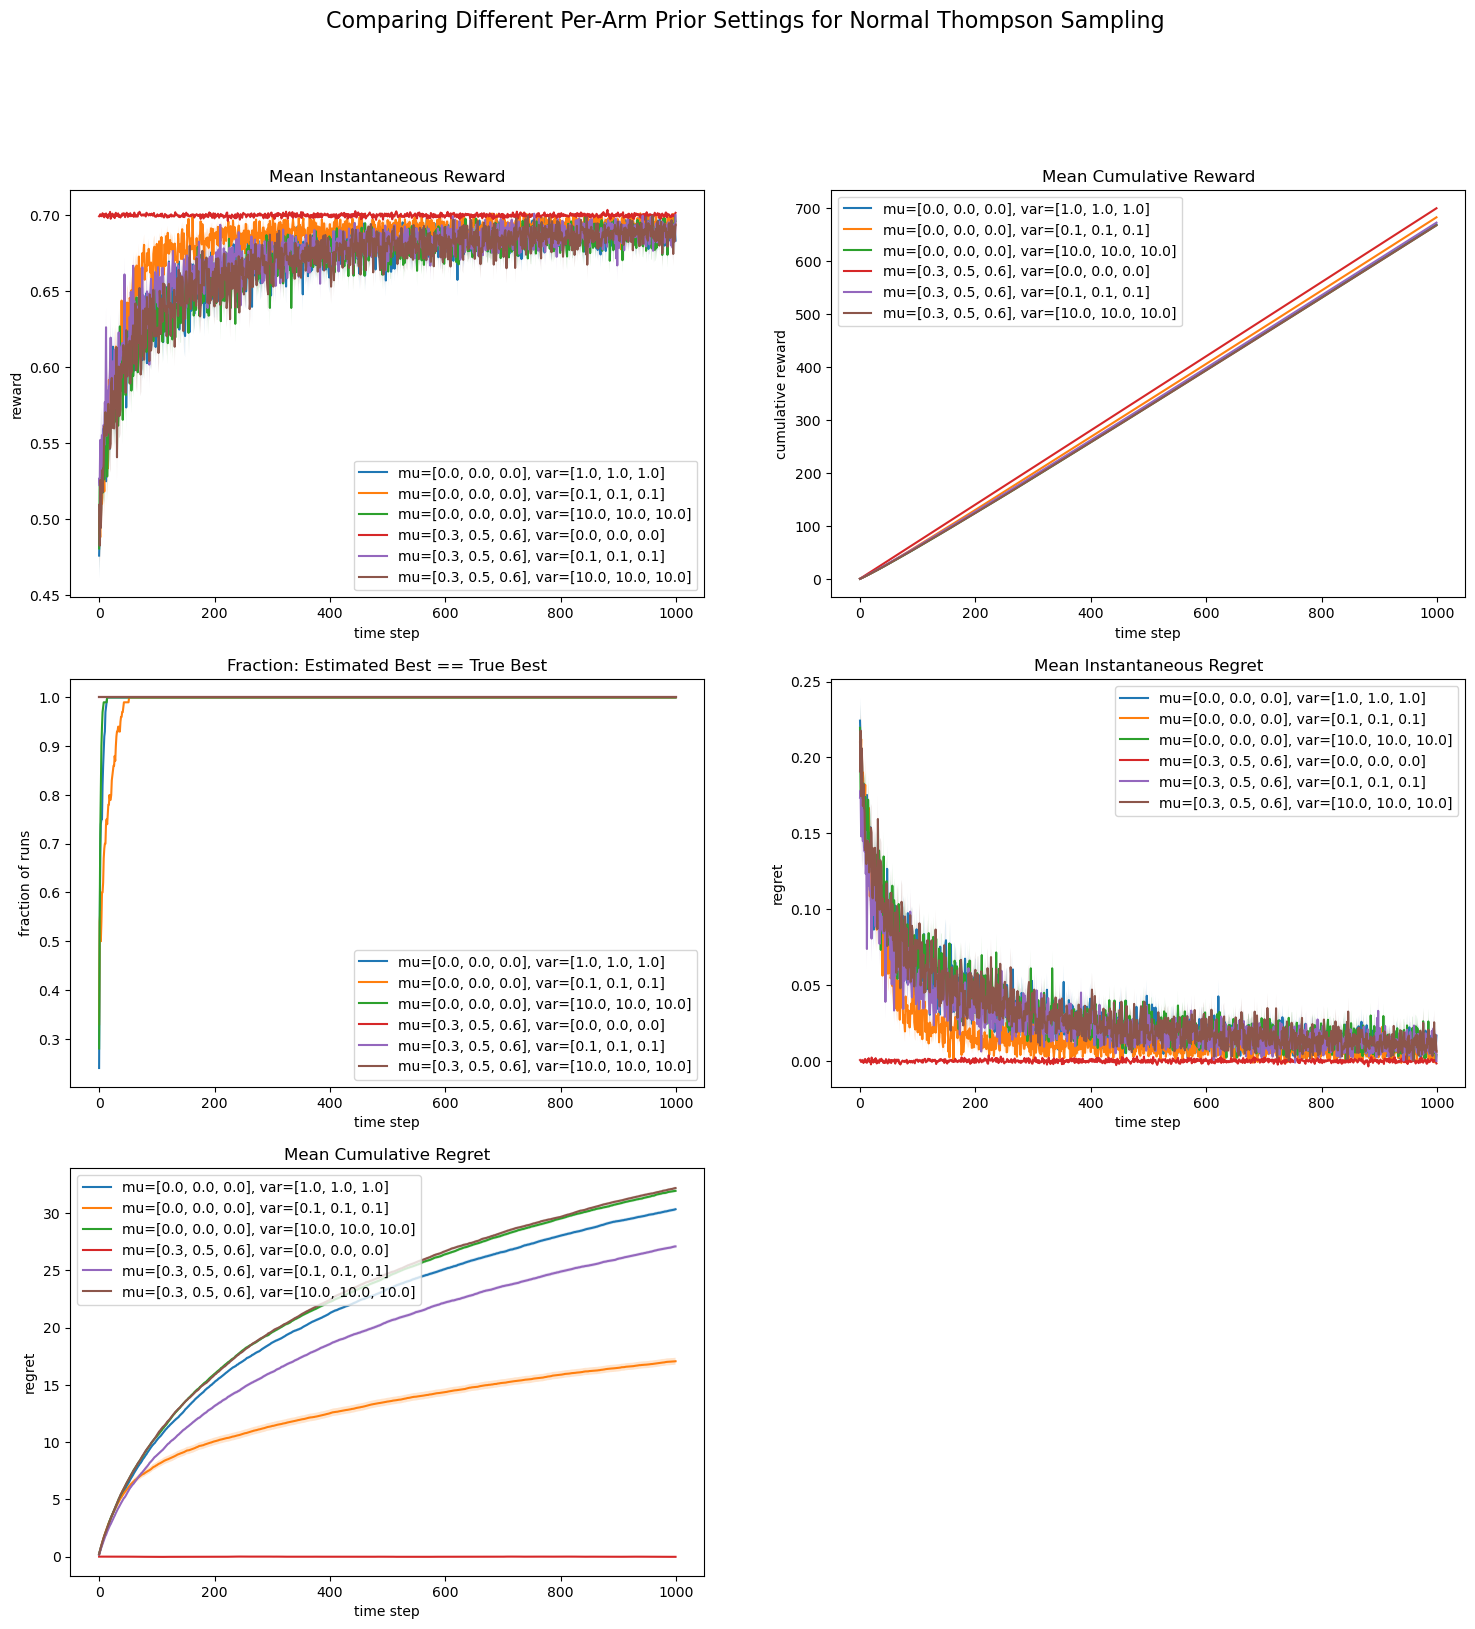

In [116]:
num_runs = 100
T = 1000

# define sets of (prior_means, prior_vars) for 3 arms:
prior_configs = [
    ([0.0, 0.0, 0.0], [1.0, 1.0, 1.0]),    # baseline
    ([0.0, 0.0, 0.0], [0.1, 0.1, 0.1]),    # smaller prior var for all arms
    ([0.0, 0.0, 0.0], [10.0, 10.0, 10.0]), # bigger prior var
    ([0.3, 0.5, 0.6], [0.0, 0.0, 0.0]),    # each arm has distinct prior
    ([0.3, 0.5, 0.6], [0.1, 0.1, 0.1]),    # each arm has distinct prior, larger prior var
    ([0.3, 0.5, 0.6], [10.0, 10.0, 10.0]),  # each arm has distinct prior, largest prior var
]

results = {}

for (prior_means, prior_vars) in prior_configs:
    # run-by-run arrays
    R_runs          = []
    total_R_runs    = []
    est_best_runs   = []
    l_runs          = []
    total_l_runs    = []

    for run in range(num_runs):
        # Thompson with these per-arm priors
        R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t = normal_thompson_sampling(
            three_arm_gaussian_bandit,
            num_time_step=T,
            init_prior_means=prior_means,
            init_prior_vars=prior_vars
        )

        R_runs.append(R_over_t)
        total_R_runs.append(total_R_over_t)
        est_best_runs.append(est_is_best_over_t)
        l_runs.append(l_over_t)
        total_l_runs.append(total_l_over_t)

    # convert to np arrays
    R_runs       = np.array(R_runs)    # shape (num_runs, T)
    total_R_runs = np.array(total_R_runs)
    est_best_runs= np.array(est_best_runs)
    l_runs       = np.array(l_runs)
    total_l_runs = np.array(total_l_runs)

    # compute means & std errors across runs
    mean_R       = R_runs.mean(axis=0)
    se_R         = R_runs.std(axis=0)/np.sqrt(num_runs)

    mean_total_R = total_R_runs.mean(axis=0)
    se_total_R   = total_R_runs.std(axis=0)/np.sqrt(num_runs)

    mean_est_best= est_best_runs.mean(axis=0)

    mean_l       = l_runs.mean(axis=0)
    se_l         = l_runs.std(axis=0)/np.sqrt(num_runs)

    mean_total_l = total_l_runs.mean(axis=0)
    se_total_l   = total_l_runs.std(axis=0)/np.sqrt(num_runs)

    # create a label for this prior setting
    label_str = f"mu={prior_means}, var={prior_vars}"
    results[label_str] = {
        'mean_R': mean_R,
        'se_R': se_R,
        'mean_total_R': mean_total_R,
        'se_total_R': se_total_R,
        'mean_est_best': mean_est_best,
        'mean_l': mean_l,
        'se_l': se_l,
        'mean_total_l': mean_total_l,
        'se_total_l': se_total_l
    }

# plot
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
time_axis = np.arange(T)

# instantaneous reward
for label in results:
    axs[0,0].plot(results[label]['mean_R'], label=label)
    axs[0,0].fill_between(
        time_axis,
        results[label]['mean_R'] - results[label]['se_R'],
        results[label]['mean_R'] + results[label]['se_R'],
        alpha=0.2
    )
axs[0,0].set_title("Mean Instantaneous Reward")
axs[0,0].set_xlabel("time step")
axs[0,0].set_ylabel("reward")
axs[0,0].legend()

# mean cumulative reward
for label in results:
    axs[0,1].plot(results[label]['mean_total_R'], label=label)
    axs[0,1].fill_between(
        time_axis,
        results[label]['mean_total_R'] - results[label]['se_total_R'],
        results[label]['mean_total_R'] + results[label]['se_total_R'],
        alpha=0.2
    )
axs[0,1].set_title("Mean Cumulative Reward")
axs[0,1].set_xlabel("time step")
axs[0,1].set_ylabel("cumulative reward")
axs[0,1].legend()

# probability best arm is chosen
for label in results:
    axs[1,0].plot(results[label]['mean_est_best'], label=label)
axs[1,0].set_title("Fraction: Estimated Best == True Best")
axs[1,0].set_xlabel("time step")
axs[1,0].set_ylabel("fraction of runs")
axs[1,0].legend()

# instantaneous regret
for label in results:
    axs[1,1].plot(results[label]['mean_l'], label=label)
    axs[1,1].fill_between(
        time_axis,
        results[label]['mean_l'] - results[label]['se_l'],
        results[label]['mean_l'] + results[label]['se_l'],
        alpha=0.2
    )
axs[1,1].set_title("Mean Instantaneous Regret")
axs[1,1].set_xlabel("time step")
axs[1,1].set_ylabel("regret")
axs[1,1].legend()

# mean cumulative regret
for label in results:
    axs[2,0].plot(results[label]['mean_total_l'], label=label)
    axs[2,0].fill_between(
        time_axis,
        results[label]['mean_total_l'] - results[label]['se_total_l'],
        results[label]['mean_total_l'] + results[label]['se_total_l'],
        alpha=0.2
    )
axs[2,0].set_title("Mean Cumulative Regret")
axs[2,0].set_xlabel("time step")
axs[2,0].set_ylabel("regret")
axs[2,0].legend()

axs[2,1].axis('off')

fig.suptitle("Comparing Different Per-Arm Prior Settings for Normal Thompson Sampling", fontsize=16)
plt.show()

### Answers

<b><u> Explain briefly the behaviour you observe </b></u>

Both the instantaneous reward and regret curves behave very similarly though in opposite directions, however, we already observe a small performance benefit for the orange curve priors selection with the purple priors closest to the former. The influence of the prior selection is best seen in the mean cumulative regret curve, where the orange priors substantially out-perform all the others. The large prior variance (e.g. 10.0) express a high initial uncertainty, leading the algorithm to explore more aggressively early on, slightly slowing its initial performance as is shown in all of the curves with $\sigma^2 >= 1$. The small prior variances (e.g. 0.1) assume strong initial confidence in the prior mean—if that mean is near the true mean, the algorithm learns very quickly, achieving higher early rewards as is shown by orange case. However, if the priors were further off, the algorithm might not have explored enough initially. Note that the red priors combination performs the best, however this is due to the prior mean being close to the true mean while the low variance expresses the certainty, which is reflective of a lucky initial guess rather than better performance.

## Q8 Comparison of Algorithms

### Hyperparameter Selection

In [57]:
def run_multiple_runs(algo_func, bandit, runs=100, T=1000, **algo_kwargs):
    """
    Utility to call an algorithm function multiple times (runs),
    then return the *average final cumulative reward* (or any metric you like)
    along with all time-step data for plotting if needed.

    Parameters
    ----------
    algo_func : function
        One of your bandit solver functions, e.g. epsilon_greedy.
    bandit : object
        Must have attributes: num_arms, mean, .sample(action)
    runs : int
        Number of independent runs to average over.
    T : int
        Number of time steps for each run.
    algo_kwargs : dict
        Hyperparameters passed to the algorithm function.

    Returns
    -------
    mean_final_cum_reward : float
        The average (over runs) of the final cumulative reward at time T.
    full_data : dict
        Contains arrays of shape (runs, T) for each quantity if you want to do further analysis.
    """
    all_rewards = []
    all_cum_rewards = []
    all_est_best = []
    all_regret = []
    all_cum_regret = []

    for _ in range(runs):
        R_over_t, total_R_over_t, est_is_best_over_t, l_over_t, total_l_over_t = algo_func(
            bandit, num_time_step=T, **algo_kwargs
        )
        all_rewards.append(R_over_t)
        all_cum_rewards.append(total_R_over_t)
        all_est_best.append(est_is_best_over_t)
        all_regret.append(l_over_t)
        all_cum_regret.append(total_l_over_t)

    # convert to np arrays
    all_rewards = np.array(all_rewards)         # shape (runs, T)
    all_cum_rewards = np.array(all_cum_rewards) # shape (runs, T)
    all_est_best = np.array(all_est_best)
    all_regret = np.array(all_regret)
    all_cum_regret = np.array(all_cum_regret)

    # pick final cumulative reward as a selection metric:
    mean_final_cum_reward = np.mean(all_cum_rewards[:, -1])

    full_data = {
        'rewards': all_rewards,
        'cum_rewards': all_cum_rewards,
        'est_best': all_est_best,
        'regret': all_regret,
        'cum_regret': all_cum_regret
    }
    print(f"Ran {runs} runs of {algo_func.__name__} with {algo_kwargs}")
    print(f"Mean final cumulative reward: {mean_final_cum_reward}")
    return mean_final_cum_reward, full_data


def pick_best_hyperparams(algo_func, bandit, param_grid, runs=100, T=1000):
    """
    Given an algorithm (algo_func) and a param_grid (list of dicts or product),
    run each combination, pick the best final-cumulative-reward combination.

    Returns the best param combination and its performance data.
    """
    best_params = None
    best_performance = -np.inf
    best_data = None

    for params in param_grid:
        # run multiple runs with these params
        final_cum, full_data = run_multiple_runs(algo_func, bandit, runs=runs, T=T, **params)

        # compare performance
        if final_cum > best_performance:
            best_performance = final_cum
            best_params = params
            best_data = full_data

    return best_params, best_performance, best_data


In [123]:
# Epsilon-Greedy
eg_param_grid = [
    {'epsilon': 0.125, 'alpha': 0.1},
    {'epsilon': 0.125, 'alpha': 0.125},
    {'epsilon': 0.125, 'alpha': None}, # incremental

    {'epsilon': 0.1, 'alpha': 0.1},
    {'epsilon': 0.1, 'alpha': 0.125}, 
    {'epsilon': 0.1, 'alpha': None}, # incremental

    {'epsilon': 0.075, 'alpha': 0.1},
    {'epsilon': 0.075, 'alpha': 0.125},
    {'epsilon': 0.075, 'alpha': None}, # incremental

    {'epsilon': 0.5, 'alpha': 0.1, 'epsilon_decay': True, 'lambda_': 0.1},
    {'epsilon': 0.5, 'alpha': None, 'epsilon_decay': True, 'lambda_': 0.1},
    {'epsilon': 0.5, 'alpha': 0.1, 'epsilon_decay': True, 'lambda_': 0.01},
    {'epsilon': 0.5, 'alpha': None, 'epsilon_decay': True, 'lambda_': 0.01}    
]

# Gradient Bandit
gb_param_grid = [
    {'alpha': 0.01, 'baseline': True, 'alpha_decay': False},
    {'alpha': 0.01, 'baseline': True, 'alpha_decay': True, 'lambda_':0.001, 'p':0.5},
    {'alpha': 0.01, 'baseline': True, 'alpha_decay': True, 'lambda_':0.01, 'p':0.5},
    {'alpha': 0.01, 'baseline': True, 'alpha_decay': True, 'lambda_':0.1, 'p':0.5},

    {'alpha': 0.075, 'baseline': True, 'alpha_decay': False},
    {'alpha': 0.075, 'baseline': True, 'alpha_decay': True, 'lambda_':0.001, 'p':0.5},
    {'alpha': 0.075, 'baseline': True, 'alpha_decay': True, 'lambda_':0.01, 'p':0.5},
    {'alpha': 0.075, 'baseline': True, 'alpha_decay': True, 'lambda_':0.1, 'p':0.5},

    {'alpha': 0.1, 'baseline': True,  'alpha_decay': False},
    {'alpha': 0.1, 'baseline': True,  'alpha_decay': True,  'lambda_':0.001, 'p':0.5},
    {'alpha': 0.1, 'baseline': True,  'alpha_decay': True,  'lambda_':0.01, 'p':0.5},
    {'alpha': 0.1, 'baseline': True,  'alpha_decay': True,  'lambda_':0.1, 'p':0.5},

    {'alpha': 0.125, 'baseline': True, 'alpha_decay': False},
    {'alpha': 0.125, 'baseline': True, 'alpha_decay': True, 'lambda_':0.001, 'p':0.5},
    {'alpha': 0.125, 'baseline': True, 'alpha_decay': True, 'lambda_':0.01, 'p':0.5},
    {'alpha': 0.125, 'baseline': True, 'alpha_decay': True, 'lambda_':0.1, 'p':0.5},

    {'alpha': 0.15, 'baseline': False, 'alpha_decay': False},
    {'alpha': 0.15, 'baseline': False, 'alpha_decay': True, 'lambda_':0.001, 'p':0.5},
    {'alpha': 0.15, 'baseline': False, 'alpha_decay': True, 'lambda_':0.01, 'p':0.5},
    {'alpha': 0.15, 'baseline': False, 'alpha_decay': True, 'lambda_':0.1, 'p':0.5}
]

# Normal Thompson
prior_configs = [
    ([0.0, 0.0, 0.0], [1.0, 1.0, 1.0]),    # baseline
    ([0.0, 0.0, 0.0], [0.1, 0.1, 0.1]),    # smaller prior var for all arms
    ([0.0, 0.0, 0.0], [10.0, 10.0, 10.0]), # bigger prior var
    # ([0.3, 0.5, 0.6], [0.0, 0.0, 0.0]),    # each arm has distinct prior means, zero var --> Too good a first guess
    ([0.3, 0.5, 0.6], [0.1, 0.1, 0.1]),    # each arm distinct prior means, small var
    ([0.3, 0.5, 0.6], [10.0, 10.0, 10.0]), # each arm distinct prior means, large var
]

nts_param_grid = [
    {'init_prior_means': means, 'init_prior_vars': vars_}
    for (means, vars_) in prior_configs
]

# Now pick best for each:
print("Epsilon-Greedy Hyperparameter Search")
best_eg_params, best_eg_perf, best_eg_data = pick_best_hyperparams(epsilon_greedy, three_arm_gaussian_bandit, eg_param_grid)
print("----------------------------")
print("Gradient Bandit Hyperparameter Search")
best_gb_params, best_gb_perf, best_gb_data = pick_best_hyperparams(gradient_bandit, three_arm_gaussian_bandit, gb_param_grid)
print("----------------------------")
print("Thompson Hyperparameter Search")
best_nts_params, best_nts_perf, best_nts_data = pick_best_hyperparams(normal_thompson_sampling, three_arm_gaussian_bandit, nts_param_grid)

Epsilon-Greedy Hyperparameter Search
Ran 100 runs of epsilon_greedy with {'epsilon': 0.125, 'alpha': 0.1}
Mean final cumulative reward: 630.7298516239384
Ran 100 runs of epsilon_greedy with {'epsilon': 0.125, 'alpha': 0.125}
Mean final cumulative reward: 633.6257198299538
Ran 100 runs of epsilon_greedy with {'epsilon': 0.125, 'alpha': None}
Mean final cumulative reward: 669.9043186360323
Ran 100 runs of epsilon_greedy with {'epsilon': 0.1, 'alpha': 0.1}
Mean final cumulative reward: 620.2609015177491
Ran 100 runs of epsilon_greedy with {'epsilon': 0.1, 'alpha': 0.125}
Mean final cumulative reward: 629.7045416650694
Ran 100 runs of epsilon_greedy with {'epsilon': 0.1, 'alpha': None}
Mean final cumulative reward: 672.1942783383182
Ran 100 runs of epsilon_greedy with {'epsilon': 0.075, 'alpha': 0.1}
Mean final cumulative reward: 592.853176931529
Ran 100 runs of epsilon_greedy with {'epsilon': 0.075, 'alpha': 0.125}
Mean final cumulative reward: 617.186093128784
Ran 100 runs of epsilon_gre

### Graphs

In [124]:
def plot_best_algos(bandit, best_eg_params, best_gb_params, best_nts_params,
                    runs=100, T=1000):
    """
    Re-run each algorithm with the selected best param combos, average over multiple runs,
    then produce a 3x2 figure comparing them.
    """

    # results in a dict for easy plotting
    algo_labels = ['Epsilon-Greedy', 'GradientBandit', 'NormalThompson']
    algo_funcs  = [epsilon_greedy, gradient_bandit, normal_thompson_sampling]
    algo_params = [best_eg_params, best_gb_params, best_nts_params]

    # store the final average time-series data for each
    results = {}

    for label, func, params in zip(algo_labels, algo_funcs, algo_params):
        # re-run to gather data
        _, full_data = run_multiple_runs(func, bandit, runs=runs, T=T, **params)

        # store the means across runs for each time-step
        R      = np.mean(full_data['rewards'], axis=0)      # shape (T,)
        cum_R  = np.mean(full_data['cum_rewards'], axis=0)
        est_b  = np.mean(full_data['est_best'], axis=0)
        reg    = np.mean(full_data['regret'], axis=0)
        cum_reg= np.mean(full_data['cum_regret'], axis=0)

        # standard errors for error bands
        se_R       = np.std(full_data['rewards'], axis=0)/np.sqrt(runs)
        se_cum_R   = np.std(full_data['cum_rewards'], axis=0)/np.sqrt(runs)
        se_reg     = np.std(full_data['regret'], axis=0)/np.sqrt(runs)
        se_cum_reg = np.std(full_data['cum_regret'], axis=0)/np.sqrt(runs)

        results[label] = {
            'mean_R'      : R,
            'mean_cum_R'  : cum_R,
            'mean_est_b'  : est_b,
            'mean_reg'    : reg,
            'mean_cum_reg': cum_reg,
            'se_R'        : se_R,
            'se_cum_R'    : se_cum_R,
            'se_reg'      : se_reg,
            'se_cum_reg'  : se_cum_reg
        }

    # plot
    fig, axs = plt.subplots(3, 2, figsize=(18, 18))
    time_axis = np.arange(T)

    # instantaneous Reward
    for label in results:
        axs[0,0].plot(results[label]['mean_R'], label=label)
        # fill error bands if desired
        axs[0,0].fill_between(
            time_axis,
            results[label]['mean_R'] - results[label]['se_R'],
            results[label]['mean_R'] + results[label]['se_R'],
            alpha=0.2
        )
    axs[0,0].set_title("Mean Instantaneous Reward")
    axs[0,0].set_xlabel("time step")
    axs[0,0].set_ylabel("reward")
    axs[0,0].legend()

    # cumulative Reward
    for label in results:
        axs[0,1].plot(results[label]['mean_cum_R'], label=label)
        axs[0,1].fill_between(
            time_axis,
            results[label]['mean_cum_R'] - results[label]['se_cum_R'],
            results[label]['mean_cum_R'] + results[label]['se_cum_R'],
            alpha=0.2
        )
    axs[0,1].set_title("Mean Cumulative Reward")
    axs[0,1].set_xlabel("time step")
    axs[0,1].set_ylabel("reward")
    axs[0,1].legend()

    # probability that best arm is chosen
    for label in results:
        axs[1,0].plot(results[label]['mean_est_b'], label=label)
    axs[1,0].set_title("Fraction of Runs: Estimated Best == True Best")
    axs[1,0].set_xlabel("time step")
    axs[1,0].set_ylabel("fraction")

    # instantaneous Regret
    for label in results:
        axs[1,1].plot(results[label]['mean_reg'], label=label)
        axs[1,1].fill_between(
            time_axis,
            results[label]['mean_reg'] - results[label]['se_reg'],
            results[label]['mean_reg'] + results[label]['se_reg'],
            alpha=0.2
        )
    axs[1,1].set_title("Mean Instantaneous Regret")
    axs[1,1].set_xlabel("time step")
    axs[1,1].set_ylabel("regret")

    # 5) Cumulative Regret
    for label in results:
        axs[2,0].plot(results[label]['mean_cum_reg'], label=label)
        axs[2,0].fill_between(
            time_axis,
            results[label]['mean_cum_reg'] - results[label]['se_cum_reg'],
            results[label]['mean_cum_reg'] + results[label]['se_cum_reg'],
            alpha=0.2
        )
    axs[2,0].set_title("Mean Cumulative Regret")
    axs[2,0].set_xlabel("time step")
    axs[2,0].set_ylabel("regret")
    axs[2,0].legend()

    axs[2,1].axis('off')

    fig.suptitle("Comparison of Best Hyperparams for Epsilon-Greedy, GradientBandit, NormalThompson", fontsize=16)
    plt.show()

Ran 100 runs of epsilon_greedy with {'epsilon': 0.5, 'alpha': None, 'epsilon_decay': True, 'lambda_': 0.1}
Mean final cumulative reward: 692.6695160776854
Ran 100 runs of gradient_bandit with {'alpha': 0.1, 'baseline': True, 'alpha_decay': True, 'lambda_': 0.001, 'p': 0.5}
Mean final cumulative reward: 687.8845728258216
Ran 100 runs of normal_thompson_sampling with {'init_prior_means': [0.0, 0.0, 0.0], 'init_prior_vars': [0.1, 0.1, 0.1]}
Mean final cumulative reward: 683.0410396239578


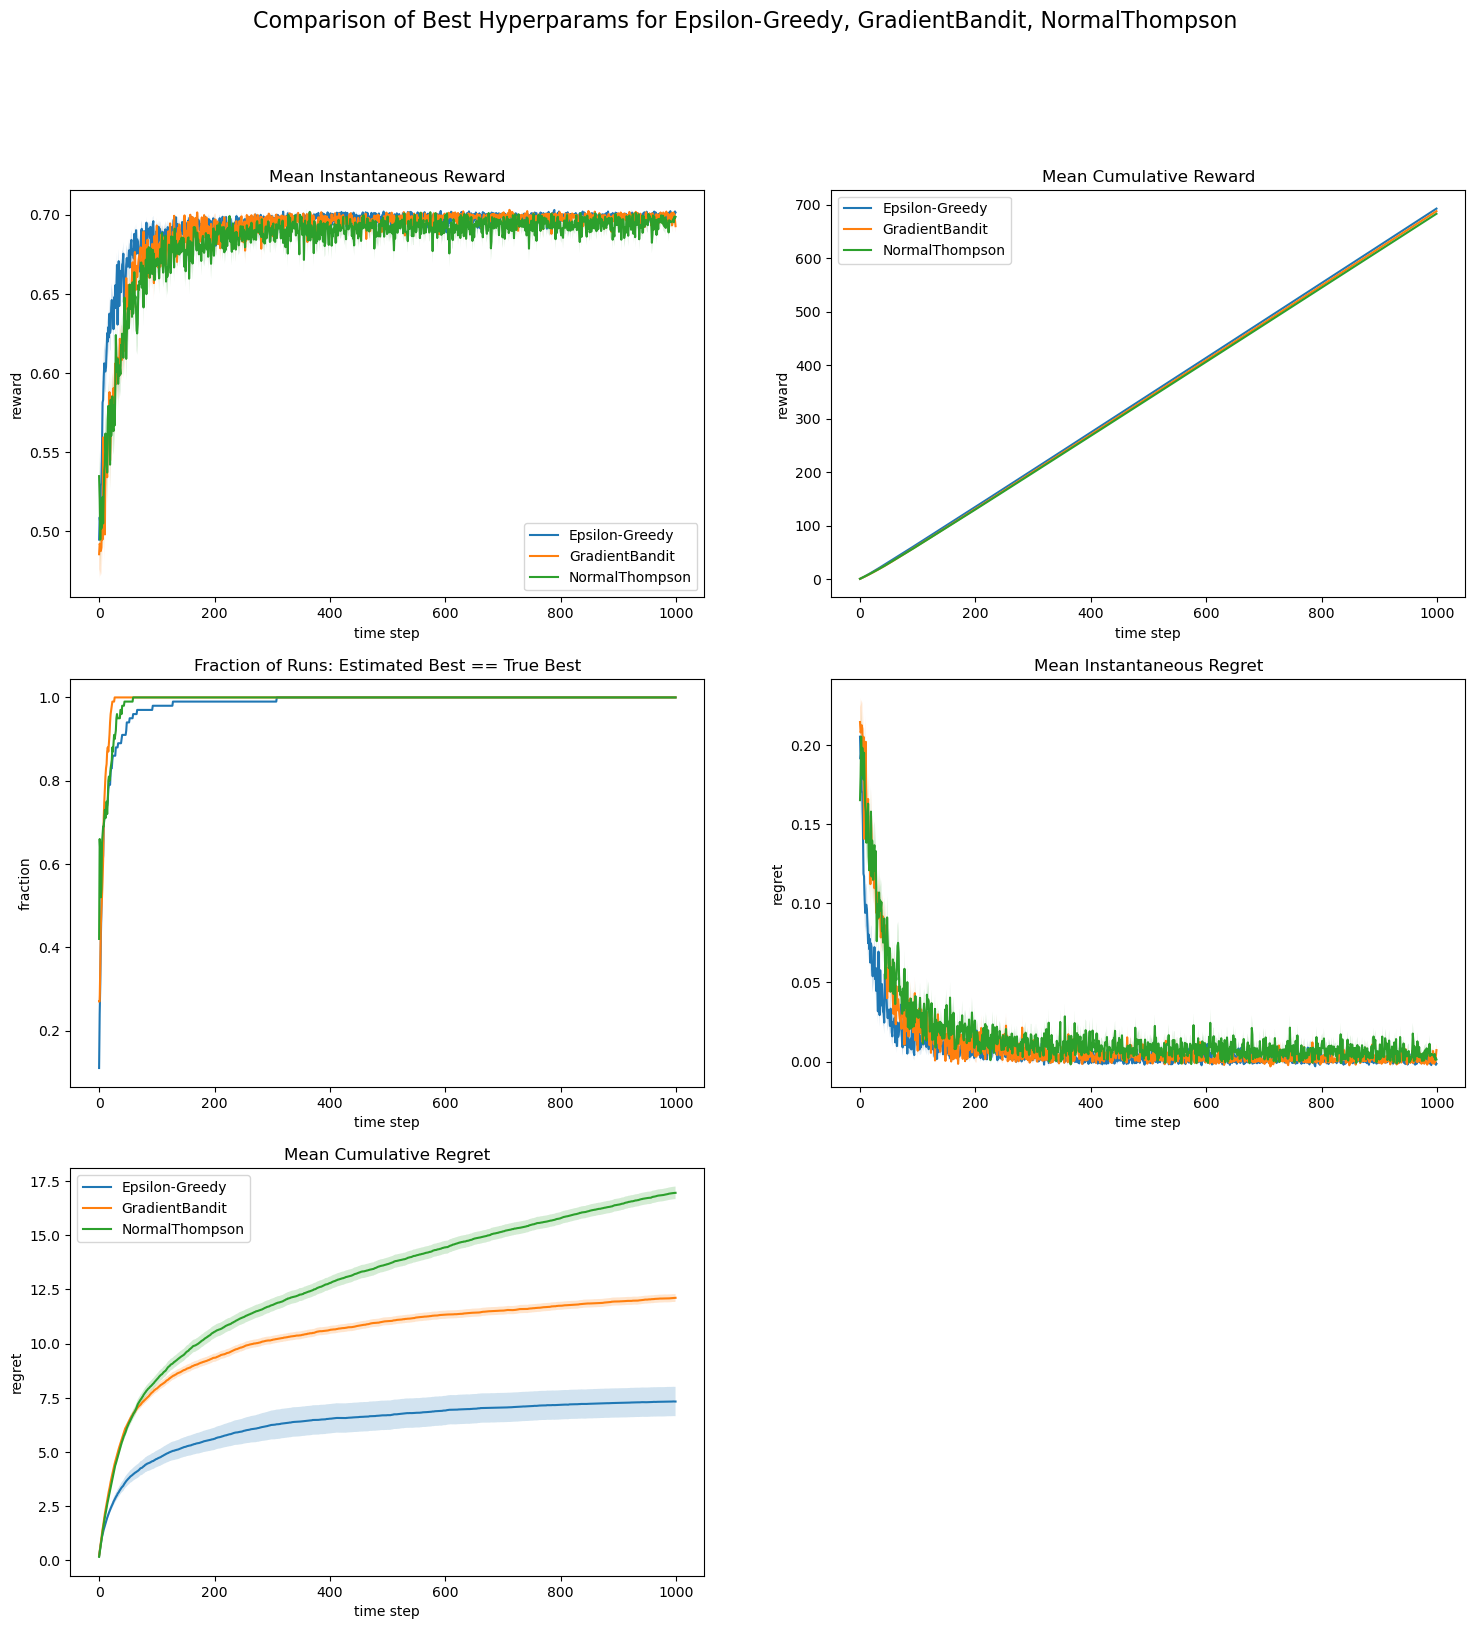

In [125]:
plot_best_algos(
    three_arm_gaussian_bandit,
    best_eg_params,
    best_gb_params,
    best_nts_params,
    runs=100,
    T=1000
)

### Answers

<b><u>Explain how you decided what ”best” means</b></u>

In my hyperparameter tuning approach, the "best" parameters were chosen by selecting the highest final mean cumulative reward. Measuring the final cumulative reward captures how well an algorithm has performed overall across the entire run: it essentially sums up all the instantaneous rewards from the first to the last time step. A higher final cumulative reward means the agent both discovered and exploited the better arms more effectively over time. By using the mean of this final cumulative reward, noise between different random outcomes of each run is reduced. Therefore, an algorithm that quickly and reliably converges to pulling the best arm will accumulate the largest total reward, so the final cumulative reward is a direct measure of how successful the algorithm has been overall.

Inspecting the graphs, it is clear that the fine-tuned $\epsilon$-greedy bandit with decay and incremental averaging outperforms the gradient bandit and Thompson approach. The main distinguishing feature between the algorithms is the cumulative regret plot which highlights the rapid leveling off of the $\epsilon$-greedy bandit, showcasing how tuning the exploration to exploitation transition through $\epsilon$ decay parameter selection and incremental averaging most quickly and thus effectively minimises regret. While the gradient bandit is tuned similarly, only having a single mechanism to maintain exploration ($\alpha$) which does not decay over time may have limited higher rewards later on, thus leading to higher regret. The Thompson algorithm may have been outperformed due to the prior selection, however, the sampling approach likely lead to slower convergence to the true mean compared to the better-tuned $\epsilon$-greedy.

Note that the Thompson algorithm could have substantially outperformed the other two methods with a prior mean selection very close to the true mean but that is more reflective of luck rather than algorithm effectiveness. Additionally, the search space for the gradient bandit could have been refined further.

## Q9 Non-stationary Environment

In [101]:
class NonStationaryGaussianBandit:
    """
    A class representing a Non-Stationary Gaussian multi-armed bandit.

    Attributes
    ----------
    num_arms : int
        Number of arms in the bandit.
    mean : np.ndarray
        Current means for each arm.
    variance : float
        Fixed variance for the rewards.
    change_point : int
        Time step at which the bandit's means are updated.
    delta : np.ndarray
        Amount by which each arm's mean changes at the change point.
    sample_count : int
        Counter for how many samples (total) have been taken.

    Methods
    -------
    sample(arm_index):
        Returns a sample from N(mean[arm_index], variance). 
        If sample_count == change_point, shift means by delta once.
    reset():
        Resets the bandit to initial conditions.
    """

    def __init__(self, num_arms, mean, variance, change_point, delta):
        self.num_arms = num_arms
        self.initial_mean = np.array(mean, dtype=float)
        self.mean = np.array(mean, dtype=float)
        self.variance = variance
        self.change_point = change_point
        self.delta = np.array(delta, dtype=float)
        self.sample_count = 0

    def sample(self, arm_index):
        # change mean at change point
        if self.sample_count == self.change_point:
            self.mean = self.mean + self.delta
        self.sample_count += 1

        return np.random.normal(self.mean[arm_index], np.sqrt(self.variance))

    def reset(self):
        # reset to initial conditions
        self.sample_count = 0
        self.mean = self.initial_mean.copy()

In [102]:
# TODO:
delta = 0.2
num_arms = 3
means = np.array([0.5, 0.5 - delta, 0.5 + delta])
variance = 0.01
num_samples = 1000

three_arm_non_stationary_gaussian_bandit = NonStationaryGaussianBandit(num_arms, means, variance, change_point=500, delta=[0.0,0.6,-0.6])

# Store the rewards for each arm
action_rewards = []
actions = range(num_arms)

for action in actions:
    # Store 50 samples per action
    rewards = []
    for _ in range(num_samples):
        reward = three_arm_non_stationary_gaussian_bandit.sample(action)
        # print(three_arm_non_stationary_gaussian_bandit.mean)
        rewards.append(reward)
    action_rewards.append(rewards)
    three_arm_non_stationary_gaussian_bandit.reset()

np.array(action_rewards).shape


(3, 1000)

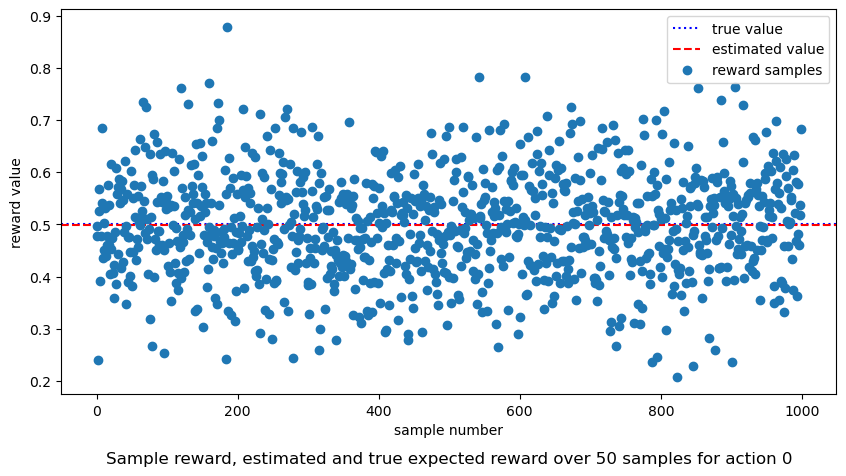

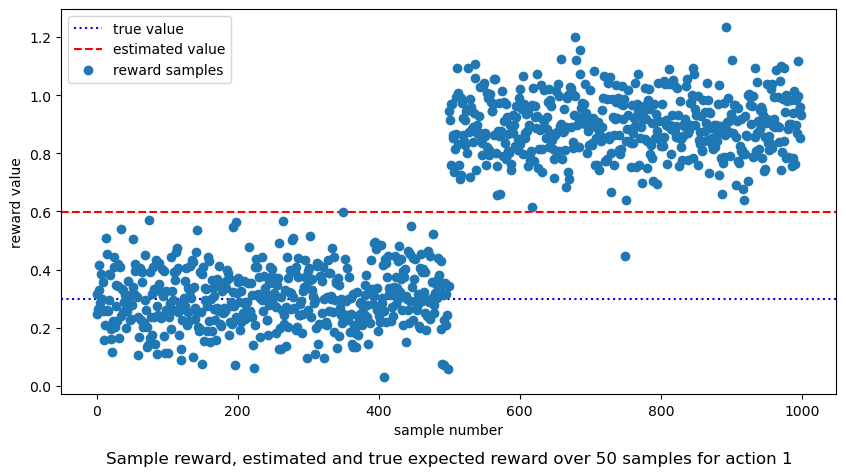

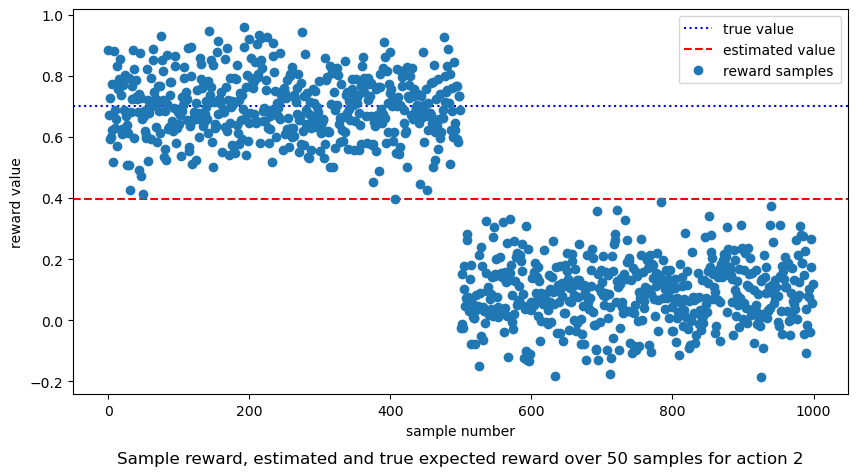

In [103]:
for action in actions:
  fig, ax = plt.subplots()

  # TODO:
  true_value = means[action] # true value of the action
  # sample mean of the rewards for the action
  estimated_value = np.mean(action_rewards[action])

  # draw the line of the true value
  line_true_val = ax.axhline(y = true_value, color = 'b', linestyle = ':', label = "true value")
  # draw the line of the estimated value
  line_est_val = ax.axhline(y = estimated_value, color = 'r', linestyle = '--', label = "estimated value")
  # plot the reward samples
  plt_samples, = ax.plot(action_rewards[action], 'o', label = "reward samples")

  ax.set_xlabel("sample number")
  ax.set_ylabel("reward value")
  ax.set_title("Sample reward, estimated and true expected reward over 50 samples for action %s" %action, y=-0.2)

  # show the legend with the labels of the line
  ax.legend(handles=[line_true_val, line_est_val, plt_samples])

### Graphs

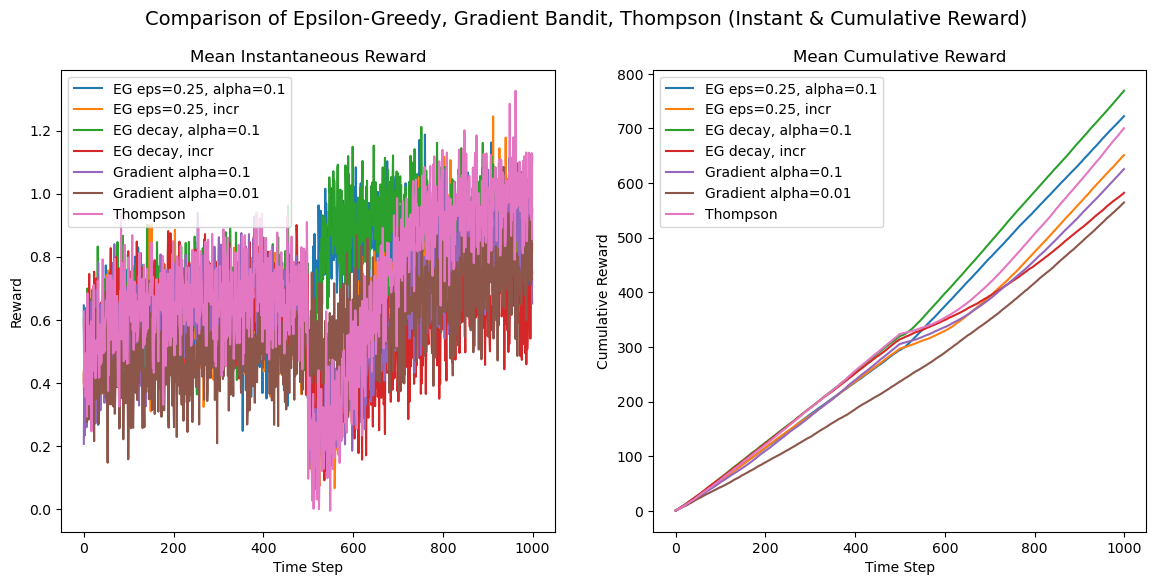

In [105]:
num_runs = 100
T = 1000

bandit = NonStationaryGaussianBandit(
    num_arms=3,
    mean=[0.5, 0.1, 0.7],
    variance=1.0,
    change_point=500,
    delta=[0.5, 0.6, -0.6]
)

# define a list of algorithm configs: (label, function, dict_of_params)
algos = [
    ("EG eps=0.25, alpha=0.1", epsilon_greedy,
     dict(epsilon=0.25, alpha=0.1, epsilon_decay=False)),

    ("EG eps=0.25, incr", epsilon_greedy,
     dict(epsilon=0.25, alpha=None, epsilon_decay=False)),

    ("EG decay, alpha=0.1", epsilon_greedy,
     dict(epsilon=0.5, alpha=0.1, epsilon_decay=True, lambda_=0.1)),

    ("EG decay, incr", epsilon_greedy,
     dict(epsilon=0.5, alpha=None, epsilon_decay=True, lambda_=0.1)),

    ("Gradient alpha=0.1", gradient_bandit,
     dict(alpha=0.1, baseline=False, alpha_decay=False)),

    ("Gradient alpha=0.01", gradient_bandit,
     dict(alpha=0.01, baseline=False, alpha_decay=False)),

    ("Thompson", normal_thompson_sampling,
     dict(num_time_step=T, init_prior_mean=0.0, init_prior_variance=1.0))
]

results = {} 

for (label, algo_func, algo_params) in algos:
    # collect reward trajectories and cumulative reward trajectories
    reward_runs = []        # shape (num_runs, T)
    cum_reward_runs = []    # shape (num_runs, T)

    for run in range(num_runs):
        # reset the bandit for each run
        bandit.reset()

        if algo_func == normal_thompson_sampling:
            # use 'num_time_step' from algo_params
            R_over_t, total_R_over_t, _, _, _ = algo_func(bandit, **algo_params)
        elif algo_func == gradient_bandit:
            # gradient_bandit(...) needs (bandit, alpha, num_time_step=..., etc.)
            R_over_t, total_R_over_t, _, _, _ = algo_func(
                bandit,
                **algo_params,
                num_time_step=T
            )
        else:
            # epsilon_greedy(...)
            R_over_t, total_R_over_t, _, _, _ = algo_func(
                bandit,
                **algo_params,
                num_time_step=T
            )

        reward_runs.append(R_over_t)
        cum_reward_runs.append(total_R_over_t)

    reward_runs      = np.array(reward_runs)      # shape (num_runs, T)
    cum_reward_runs  = np.array(cum_reward_runs)  # shape (num_runs, T)

    # mean and std error across runs
    mean_reward      = np.mean(reward_runs, axis=0)
    se_reward        = np.std(reward_runs, axis=0)/np.sqrt(num_runs)

    mean_cum_reward  = np.mean(cum_reward_runs, axis=0)
    se_cum_reward    = np.std(cum_reward_runs, axis=0)/np.sqrt(num_runs)

    # store these for plotting
    results[label] = {
        'mean_R'     : mean_reward,
        'se_R'       : se_reward,
        'mean_cum_R' : mean_cum_reward,
        'se_cum_R'   : se_cum_reward
    }

# now we produce a single figure with 2 subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(14,6))
time_axis = np.arange(T)

# instantaneous Reward
for label in results:
    axs[0].plot(time_axis, results[label]['mean_R'], label=label)
    # Optional: fill standard error
    # axs[0].fill_between(
    #     time_axis,
    #     results[label]['mean_R'] - results[label]['se_R'],
    #     results[label]['mean_R'] + results[label]['se_R'],
    #     alpha=0.2
    # )

axs[0].set_title("Mean Instantaneous Reward")
axs[0].set_xlabel("Time Step")
axs[0].set_ylabel("Reward")
axs[0].legend()

# mean Cumulative Reward
for label in results:
    axs[1].plot(time_axis, results[label]['mean_cum_R'], label=label)
    # Optional: fill standard error
    # axs[1].fill_between(
    #     time_axis,
    #     results[label]['mean_cum_R'] - results[label]['se_cum_R'],
    #     results[label]['mean_cum_R'] + results[label]['se_cum_R'],
    #     alpha=0.2
    # )

axs[1].set_title("Mean Cumulative Reward")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Cumulative Reward")
axs[1].legend()

fig.suptitle("Comparison of Epsilon-Greedy, Gradient Bandit, Thompson (Instant & Cumulative Reward)", fontsize=14)
plt.show()

### Answers

<b><u>Explain briefly what you observe in the graph. Based on these results, which algorithm is best suited to cope with non-stationarity? Discuss how each algorithm responds to the parameter change at $t= 500$ and its ability to adapt.</b></u>

Inspecting the instantaneous‐reward curves, it is clear that all algorithms undergo a dip or a jump around the time step $t=500$, due to the change in the bandit’s means. The algorithms with higher learning rates or that retain some exploration (primarily $\epsilon$-greedy with $\epsilon = 0.25$ and $\epsilon$ decay with $\alpha=0.1$) adapt more quickly after the change point, leading to higher post‐change rewards (blue and green curves). Moreover, due to this superior recovery, these two methods end on the highest cumulative mean rewards, though other methods approach these high final rewards faster toward the end of the time steps (e.g. pink Thompson past $t=900$) Meanwhile, small‐$\alpha$ or purely incremental methods ($\epsilon$-greedy incr, red and orange) are slower to adjust once they have settled on the first set of means and to the old best arm. This is reflected in a poorer cumuulative reward gain after the change at $t=500$ as well as a shallower slope in some cases (e.g. $\epsilon$-greedy incr, red curve). The gradient bandits perform relatively weakly compared to the other methods as they either recover slowly following the change (e.g. $\alpha=0.1$) or have a learning rate so slow that they are comprehensively outperformed across the board (e.g. $\alpha$=0.01). Thompson sampling, while strong initially, did not revisit other arms as aggressively once it had built up confidence due to the sampling based mean estimation, as seen by the sharp drop and relatively slow response after $t=500$.

Overall, methods that keep a reasonable level of ongoing exploration (or a sufficiently high update step size), such as $\epsilon$-greedy decay with fixed $/alpha$, are better at coping with non‐stationarity. In these results, the decaying $\epsilon$‐greedy with a fixed and relativley high learning rate handle the sudden change at $t=500$ most effectively, reflected by their quicker rise in average reward and cumulative reward after the shift. However, the Thompson approach also performs relatively well given enough time after the change.